In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, minmax_scale, scale
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/gdrive', force_remount=True)
drive.mount('/content/drive')

'''
!pip install hyperas
!pip install hyperopt==0.2.5
'''

import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from tensorflow.keras.utils import plot_model
from keras.models import load_model
import os
import math

from datetime import datetime
import time

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#from hyperas.distributions import choice
#import hyperas
#import hyperopt
#from hyperas import optim
#from hyperopt import Trials, STATUS_OK, tpe

# Cargamos las BD de train y test

# Para kaggle
#INPUT_FILE_NAME_X = "/kaggle/input/d/srguille/hotelreservations/HotelReservationsPreparedCleanAttributes.csv"
#INPUT_FILE_NAME_Y = "/kaggle/input/d/srguille/hotelreservations/HotelReservationsOutput.csv"

# Para drive
INPUT_FILE_NAME_X = "/content/drive/MyDrive/Redes_neuronas/HotelReservationsPreparedCleanAttributes.csv"
INPUT_FILE_NAME_Y = "/content/drive/MyDrive/Redes_neuronas/HotelReservationsOutput.csv"
attributes = pd.read_csv(INPUT_FILE_NAME_X)
label = pd.read_csv(INPUT_FILE_NAME_Y)
TEST_RATIO = 0.2

keras.utils.set_random_seed(812)

# Primero dividir a 80% train y 20% test
X_train, X_test, y_train, y_test = train_test_split(attributes,label,test_size=TEST_RATIO)

# Dividir el de 20% entre dos iguales: 10% cada uno
X_test, X_dev, y_test, y_dev = train_test_split(X_test,y_test,test_size=0.5)

print('Train set: ',X_train.shape[0]/attributes.shape[0])
print('Development set: ', X_dev.shape[0]/attributes.shape[0])
print('Test set: ',X_test.shape[0]/attributes.shape[0])

HUMAN_ERROR = 0.05

def print_results(history, cost):
    a = np.argmax(history.history['val_binary_accuracy'])
    epochs = len(history.history['val_binary_accuracy']) # Numero de epocas real en caso de early stopping
    train_accuracy, val_accuracy = history.history['binary_accuracy'][a], history.history['val_binary_accuracy'][a]
    print(f'Mejor accuracy de validación {val_accuracy:.3f} en época {a} con accuracy de train {train_accuracy:.3f}')
    print(f'Diferencia error humano y accuracy de train {((1 - train_accuracy) - HUMAN_ERROR) * 100:.3f} %')
    print(f'Diferencia accuracy de train y accuracy de validación {(train_accuracy - val_accuracy) * 100:.3f} %')
    print(f'Número de épocas {epochs}')
    print(f'Segundos de ejecución por época {cost/epochs:.3f}')


def get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.97, staircase=True):
    return tf.keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate,
        decay_steps=(training_size * 0.9)//initial_bs,
        decay_rate=decay_rate,
        staircase=staircase)

def capa(model,n_neuronas):
    model.add(keras.layers.Dense(n_neuronas))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation('selu'))

class Learning_rate_tracker(keras.callbacks.Callback):
    def __init__(self):
        self.lista_lr = []
    def on_epoch_end(self, epoch, logs=None):
        self.lista_lr.append(self.model.optimizer.learning_rate.numpy())
    def plot_lrate(self):
        fig1, ax1 = plt.subplots(figsize = (6,3))
        ax1.plot(self.lista_lr)
        ax1.set_ylabel('Learning rate')
        ax1.set_xlabel('Step')

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['navy', 'darkred', 'skyblue', 'lightcoral'])


Mounted at /gdrive
Mounted at /content/drive
Train set:  0.8
Development set:  0.1
Test set:  0.1


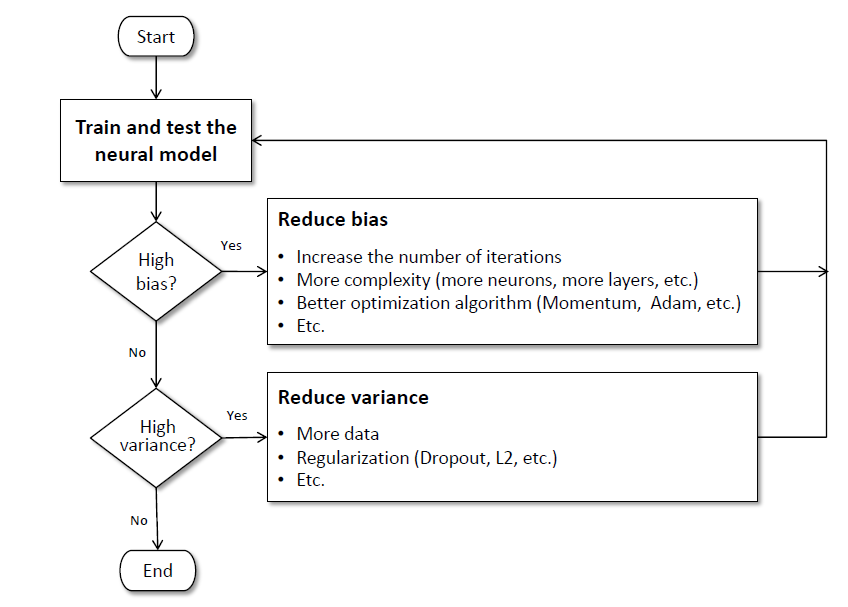

Reducir bias:
  - Aumentar capas y neuronas
  - Algoritmos de optimización --> SDG, Momentum, Nesterov, Adam, RMSProp, ADAMW
  - LR: 10^-r | 0<r<4
    - Decay: exponencial...
  - Aumentar épocas
  - Tamaño del mini-batch

Reducir varianza:
  - Regularización L1 y L2
  - Dropout: antes o después de la activación.
  - Normalización: Batch normalization.

Funciones de activación: relu, softplus, elu, selu, leakyrelu. Vanishing gradient problem.

Inicialización de pesos: he (con relu) y xavier (tanh)   



# Primeros modelos para reducir Bias

## 1. Batch Gradient Descent. Red neuronal 1 capa, lr 0.01. Optimizador SGD. Binary crossentropy. Epocas 200.

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

initial_lrate = 0.01
epochs = 200

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history = model.fit(X_train, y_train,
                    epochs=epochs,
                    verbose=0,
                    validation_data = (X_dev, y_dev))
cost = time.time() - st


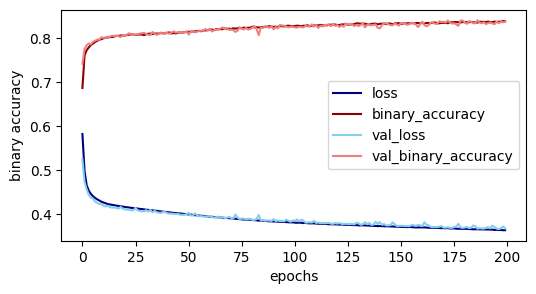

In [ ]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['navy', 'darkred', 'skyblue', 'lightcoral'])
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history, cost)

Mejor accuracy de validación 0.840 en época 186 con accuracy de train 0.835
Diferencia error humano y accuracy de train 11.522 %
Diferencia accuracy de train y accuracy de validación -0.531 %
Número de épocas 200
Segundos de ejecución por época 2.635


Conclusiones: reducir épocas, earling stopping más impaciente.

La varianza es baja (no hay overfitting) ya que el error de train y validación son muy similares.
El bias es alto ya que el error humano es el 5% y el error de train del 12% aproximadamente.

Hay que reducir bias: aumentamos número de neuronas.



## 2. Introducción de early_stopping

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 250

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_early = model.fit(X_train, y_train,
                    epochs=epochs,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_early = time.time() - st

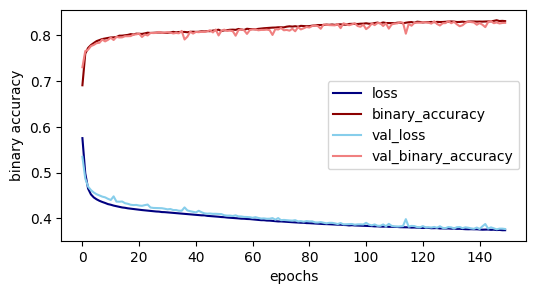

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_early.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history_early.history.keys())

In [ ]:
print_results(history_early, cost)

Mejor accuracy de validación 0.831 en época 129 con accuracy de train 0.830
Diferencia error humano y accuracy de train 11.998 %
Diferencia accuracy de train y accuracy de validación -0.124 %
Número de épocas 150
Segundos de ejecución por época 3.755


## 3. Mismo modelo pero utilizando mini-batch gradient descent

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_mini_batch_128 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])
cost_mini_batch_128 = time.time() - st


In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 256

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_mini_batch_256 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])
cost_mini_batch_256 = time.time() - st


In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 512

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_mini_batch_512 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])
cost_mini_batch_512 = time.time() - st


(0.4, 0.82)

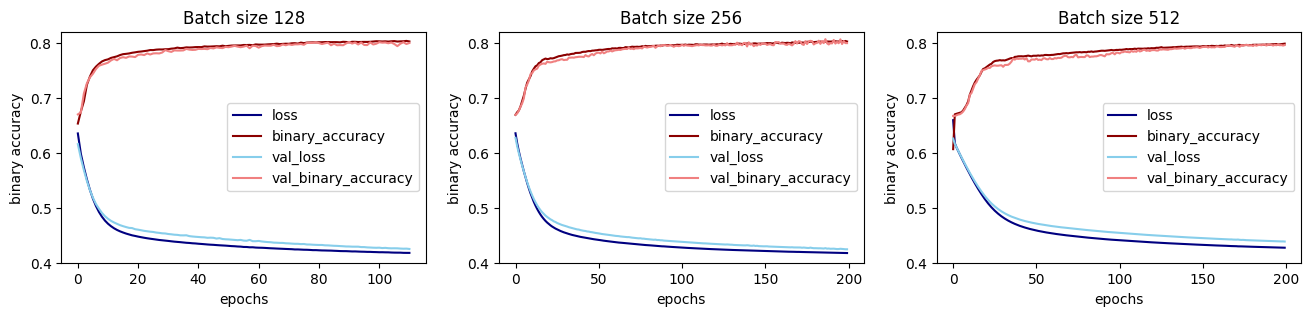

In [ ]:
fig1, ax1 = plt.subplots(1,3, figsize = (16,3))
ax1[0].plot(pd.DataFrame(history_mini_batch_128.history))
ax1[0].legend(history.history.keys())
ax1[1].plot(pd.DataFrame(history_mini_batch_256.history))
ax1[1].legend(history.history.keys())
ax1[2].plot(pd.DataFrame(history_mini_batch_512.history))
ax1[2].legend(history.history.keys())

ax1[0].set_title('Batch size 128')
ax1[1].set_title('Batch size 256')
ax1[2].set_title('Batch size 512')

ax1[0].set_ylabel('binary accuracy')
ax1[0].set_xlabel('epochs')
ax1[0].set_ylim(0.4,0.82)
ax1[1].set_ylabel('binary accuracy')
ax1[1].set_xlabel('epochs')
ax1[1].set_ylim(0.4,0.82)
ax1[2].set_ylabel('binary accuracy')
ax1[2].set_xlabel('epochs')
ax1[2].set_ylim(0.4,0.82)

In [ ]:
print_results(history_mini_batch_128, cost_mini_batch_128)

Mejor accuracy de validación 0.808 en época 88 con accuracy de train 0.803
Diferencia error humano y accuracy de train 14.710 %
Diferencia accuracy de train y accuracy de validación -0.465 %
Número de épocas 109
Segundos de ejecución por época 1.257


In [ ]:
print_results(history_mini_batch_256, cost_mini_batch_256)

Mejor accuracy de validación 0.806 en época 186 con accuracy de train 0.802
Diferencia error humano y accuracy de train 14.813 %
Diferencia accuracy de train y accuracy de validación -0.458 %
Número de épocas 200
Segundos de ejecución por época 0.429


In [ ]:
print_results(history_mini_batch_512, cost_mini_batch_512)

Mejor accuracy de validación 0.797 en época 190 con accuracy de train 0.797
Diferencia error humano y accuracy de train 15.341 %
Diferencia accuracy de train y accuracy de validación -0.021 %
Número de épocas 200
Segundos de ejecución por época 0.412


Teoría:

1) Mini-batch gradient descent employs a mini-batch in each learning iteration. This strategy is more exploratory (avoids falling in local optima) than the batch update, producing unstable learning curves.

2) Mini-batch gradient descent can be faster than the batch approach when the mini-batch size fits the GPU memory.

El resultado de ambas ha sido muy similar, posiblemente debido a que el modelo es aún muy simple como para ver las diferencias. Vamos a quedarnos con el mini-batch.


## 4. Probar a aumentar número de neuronas

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_neuronas = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_neuronas = time.time() - st


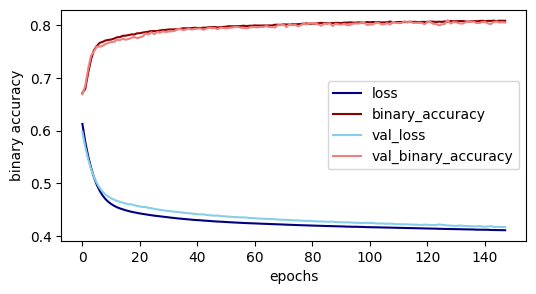

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_neuronas.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history_aumentando_neuronas.history.keys())

In [ ]:
print_results(history_aumentando_neuronas, cost_neuronas)

Mejor accuracy de validación 0.810 en época 127 con accuracy de train 0.807
Diferencia error humano y accuracy de train 14.282 %
Diferencia accuracy de train y accuracy de validación -0.258 %
Número de épocas 148
Segundos de ejecución por época 0.725


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas = time.time() - st


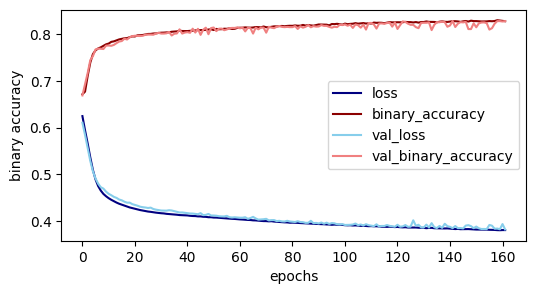

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history_aumentando_capas.history.keys())

In [ ]:
print_results(history_aumentando_capas, cost_capas)

Mejor accuracy de validación 0.829 en época 141 con accuracy de train 0.828
Diferencia error humano y accuracy de train 12.166 %
Diferencia accuracy de train y accuracy de validación -0.045 %
Número de épocas 162
Segundos de ejecución por época 0.802


(0.35, 0.85)

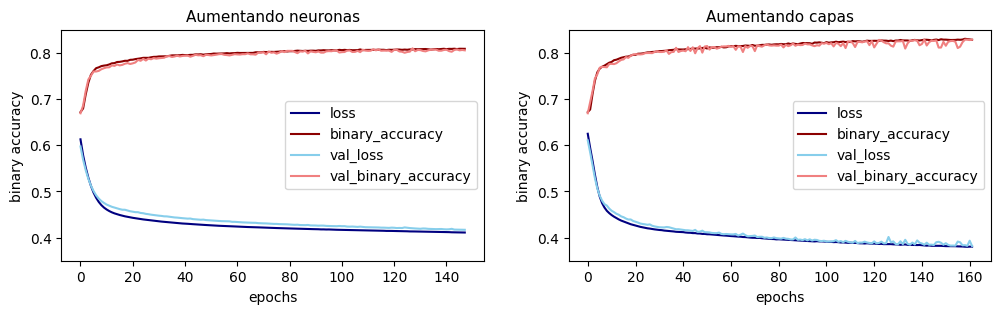

In [ ]:
fig1, ax1 = plt.subplots(1,2, figsize = (12,3))
ax1[0].plot(pd.DataFrame(history_aumentando_neuronas.history))
ax1[0].legend(history.history.keys())
ax1[1].plot(pd.DataFrame(history_aumentando_capas.history))
ax1[1].legend(history.history.keys())

ax1[0].set_title('Aumentando neuronas', fontsize = 11)
ax1[1].set_title('Aumentando capas', fontsize = 11)

ax1[0].set_ylabel('binary accuracy')
ax1[0].set_xlabel('epochs')
ax1[0].set_ylim(0.35,0.85)
ax1[1].set_ylabel('binary accuracy')
ax1[1].set_xlabel('epochs')
ax1[1].set_ylim(0.35,0.85)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_2 = time.time() - st


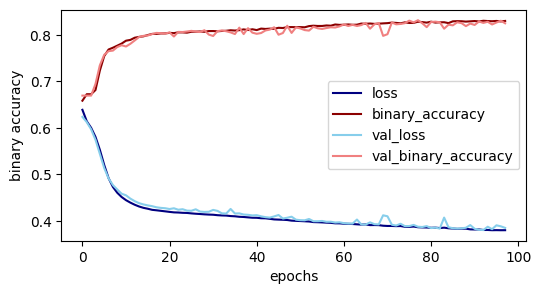

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_2.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_2, cost_capas_2)

Mejor accuracy de validación 0.831 en época 77 con accuracy de train 0.828
Diferencia error humano y accuracy de train 12.197 %
Diferencia accuracy de train y accuracy de validación -0.324 %
Número de épocas 98
Segundos de ejecución por época 1.030


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_3 = time.time() - st


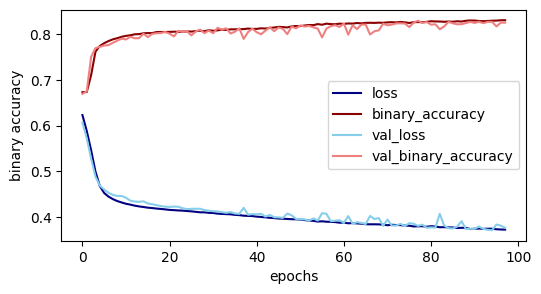

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_3.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_3, cost_capas_3)

Mejor accuracy de validación 0.829 en época 77 con accuracy de train 0.826
Diferencia error humano y accuracy de train 12.370 %
Diferencia accuracy de train y accuracy de validación -0.303 %
Número de épocas 98
Segundos de ejecución por época 0.819


(0.35, 0.85)

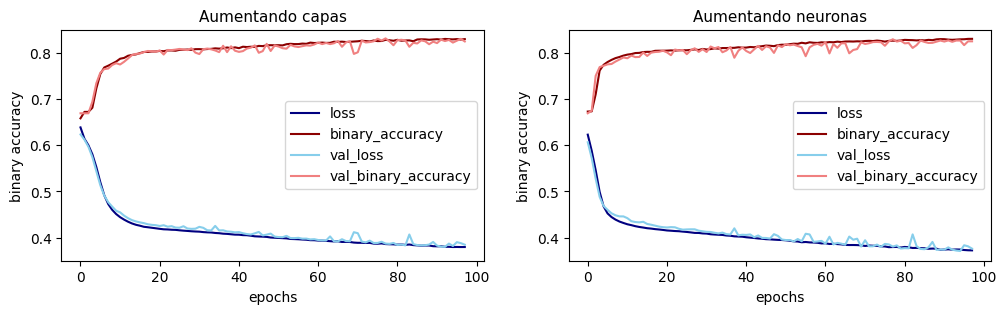

In [ ]:
fig1, ax1 = plt.subplots(1,2, figsize = (12,3))
ax1[0].plot(pd.DataFrame(history_aumentando_capas_2.history))
ax1[0].legend(history.history.keys())
ax1[1].plot(pd.DataFrame(history_aumentando_capas_3.history))
ax1[1].legend(history.history.keys())

ax1[0].set_title('Aumentando capas', fontsize = 11)
ax1[1].set_title('Aumentando neuronas', fontsize = 11)

ax1[0].set_ylabel('binary accuracy')
ax1[0].set_xlabel('epochs')
ax1[0].set_ylim(0.35,0.85)
ax1[1].set_ylabel('binary accuracy')
ax1[1].set_xlabel('epochs')
ax1[1].set_ylim(0.35,0.85)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_4 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_4 = time.time() - st

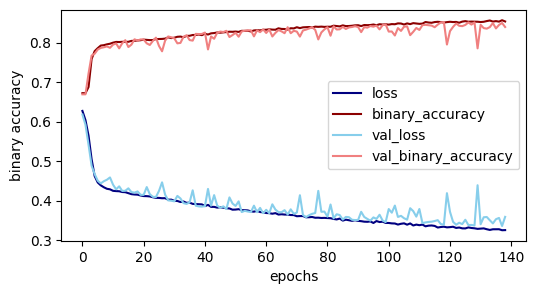

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_4.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_4, cost_capas_4)

Mejor accuracy de validación 0.852 en época 118 con accuracy de train 0.851
Diferencia error humano y accuracy de train 9.933 %
Diferencia accuracy de train y accuracy de validación -0.128 %
Número de épocas 139
Segundos de ejecución por época 1.004


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_5 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_5 = time.time() - st

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_5.history))
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_5, cost_capas_5)

Mejor accuracy de validación 0.869 en época 197 con accuracy de train 0.873
Diferencia error humano y accuracy de train 7.727 %
Diferencia accuracy de train y accuracy de validación 0.396 %
Número de épocas 200
Segundos de ejecución por época 1.001


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_6 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_6 = time.time() - st

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_6.history))
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_6, cost_capas_6)

Mejor accuracy de validación 0.867 en época 140 con accuracy de train 0.873
Diferencia error humano y accuracy de train 7.652 %
Diferencia accuracy de train y accuracy de validación 0.665 %
Número de épocas 161
Segundos de ejecución por época 1.513


(0.26, 0.89)

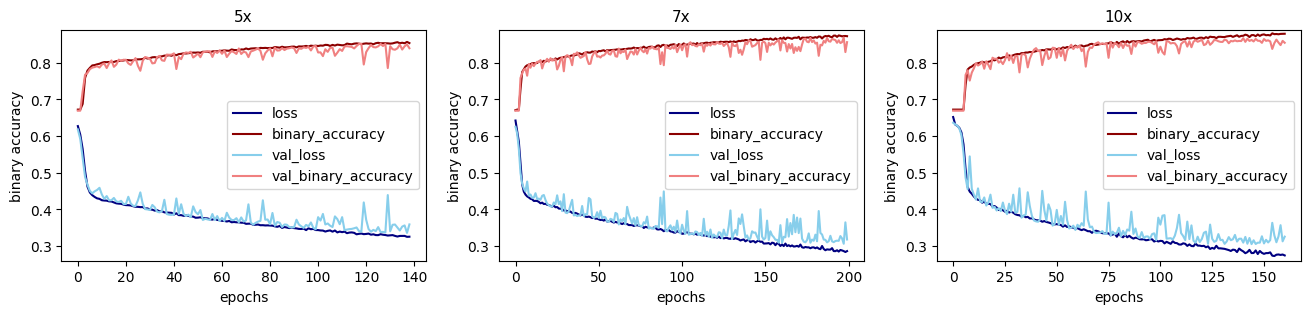

In [ ]:
fig1, ax1 = plt.subplots(1,3, figsize = (16,3))
ax1[0].plot(pd.DataFrame(history_aumentando_capas_4.history))
ax1[0].legend(history.history.keys())
ax1[1].plot(pd.DataFrame(history_aumentando_capas_5.history))
ax1[1].legend(history.history.keys())
ax1[2].plot(pd.DataFrame(history_aumentando_capas_6.history))
ax1[2].legend(history.history.keys())

ax1[0].set_title('5x', fontsize = 11)
ax1[1].set_title('7x', fontsize = 11)
ax1[2].set_title('10x', fontsize = 11)

ax1[0].set_ylabel('binary accuracy')
ax1[0].set_xlabel('epochs')
ax1[0].set_ylim(0.26,0.89)
ax1[1].set_ylabel('binary accuracy')
ax1[1].set_xlabel('epochs')
ax1[1].set_ylim(0.26,0.89)
ax1[2].set_ylabel('binary accuracy')
ax1[2].set_xlabel('epochs')
ax1[2].set_ylim(0.26,0.89)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_7 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_7 = time.time() - st

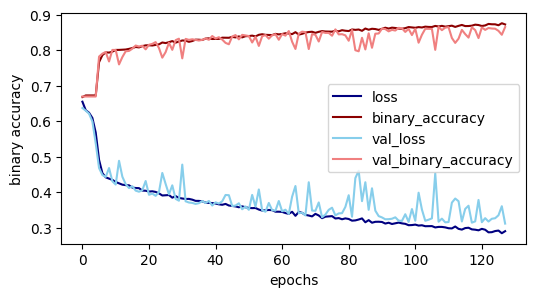

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_7.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_7, cost_capas_7)

Mejor accuracy de validación 0.865 en época 107 con accuracy de train 0.866
Diferencia error humano y accuracy de train 8.358 %
Diferencia accuracy de train y accuracy de validación 0.096 %
Número de épocas 128
Segundos de ejecución por época 1.404


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_8 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_8 = time.time() - st

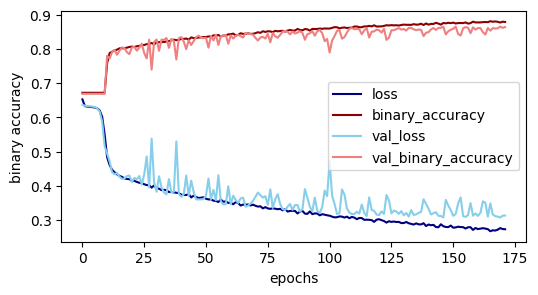

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_8.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_8, cost_capas_8)

Mejor accuracy de validación 0.865 en época 151 con accuracy de train 0.875
Diferencia error humano y accuracy de train 7.538 %
Diferencia accuracy de train y accuracy de validación 0.917 %
Número de épocas 172
Segundos de ejecución por época 1.297


(0.26, 0.89)

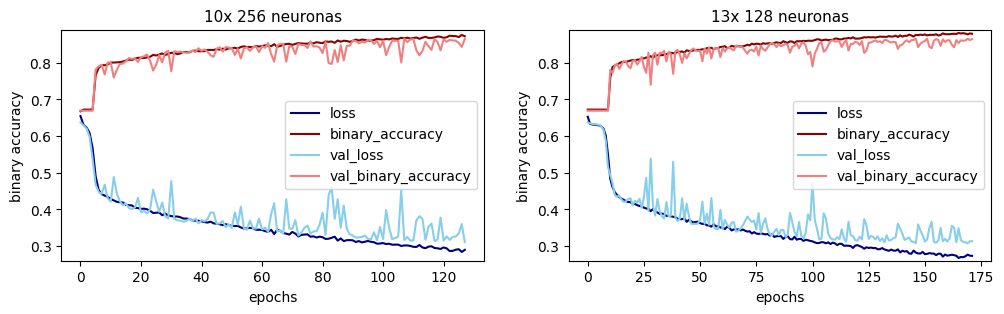

In [ ]:
fig1, ax1 = plt.subplots(1,2, figsize = (12,3))
ax1[0].plot(pd.DataFrame(history_aumentando_capas_7.history))
ax1[0].legend(history.history.keys())
ax1[1].plot(pd.DataFrame(history_aumentando_capas_8.history))
ax1[1].legend(history.history.keys())

ax1[0].set_title('10x 256 neuronas', fontsize = 11)
ax1[1].set_title('13x 128 neuronas', fontsize = 11)

ax1[0].set_ylabel('binary accuracy')
ax1[0].set_xlabel('epochs')
ax1[0].set_ylim(0.26,0.89)
ax1[1].set_ylabel('binary accuracy')
ax1[1].set_xlabel('epochs')
ax1[1].set_ylim(0.26,0.89)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_9 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_9 = time.time() - st

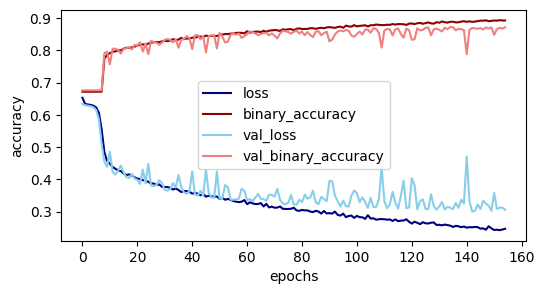

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_9.history))
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_9, cost_capas_9)

Mejor accuracy de validación 0.872 en época 134 con accuracy de train 0.888
Diferencia error humano y accuracy de train 6.201 %
Diferencia accuracy de train y accuracy de validación 1.620 %
Número de épocas 155
Segundos de ejecución por época 1.343


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_10 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_10 = time.time() - st

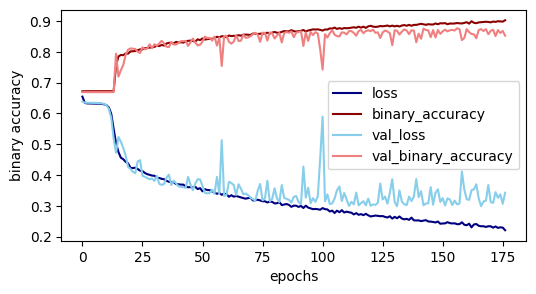

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_10.history))
ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())

In [ ]:
print_results(history_aumentando_capas_10, cost_capas_10)

Mejor accuracy de validación 0.876 en época 156 con accuracy de train 0.893
Diferencia error humano y accuracy de train 5.656 %
Diferencia accuracy de train y accuracy de validación 1.696 %
Número de épocas 177
Segundos de ejecución por época 1.733


(0.21, 0.92)

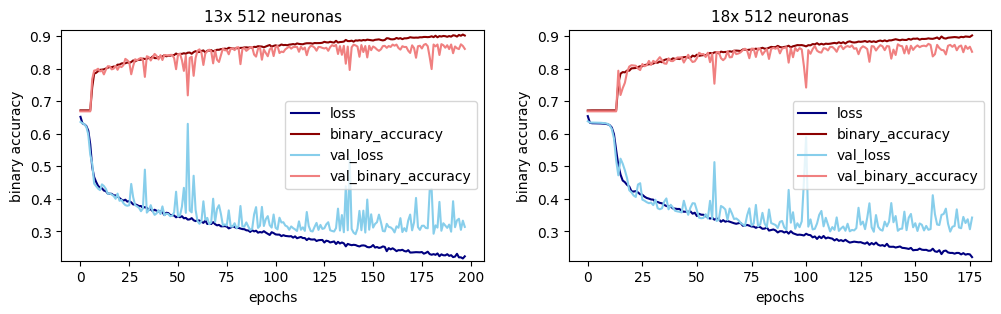

In [ ]:
fig1, ax1 = plt.subplots(1,2, figsize = (12,3))
ax1[0].plot(pd.DataFrame(history_aumentando_capas_9.history))
ax1[0].legend(history.history.keys())
ax1[1].plot(pd.DataFrame(history_aumentando_capas_10.history))
ax1[1].legend(history.history.keys())

ax1[0].set_title('13x 512 neuronas', fontsize = 11)
ax1[1].set_title('18x 512 neuronas', fontsize = 11)

ax1[0].set_ylabel('binary accuracy')
ax1[0].set_xlabel('epochs')
ax1[0].set_ylim(0.21,0.92)
ax1[1].set_ylabel('binary accuracy')
ax1[1].set_xlabel('epochs')
ax1[1].set_ylim(0.21,0.92)

In [ ]:
# Se prueba BN ya que los resultados de tener 18 capas son peores que con 13
'''
def capa_bn(model,n_neuronas):
    model.add(keras.layers.Dense(n_neuronas))
    model.add(keras.layers.BatchNormalization())
    model.add(keras.layers.Activation('relu'))

st = time.time()

model = keras.models.Sequential()
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
capa_bn(model, 512)
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_aumentando_capas_10_bn = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_capas_10_bn = time.time() - st
'''

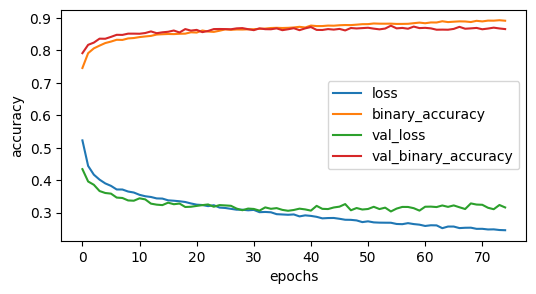

In [ ]:
'''
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_aumentando_capas_10_bn.history))
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epochs')
ax1.legend(history.history.keys())
'''

In [ ]:
#print_results(history_aumentando_capas_10_bn, cost_capas_10_bn)

Mejor accuracy de validación 0.876 en época 54 con accuracy de train 0.882
Diferencia error humano y accuracy de train 6.780 %
Diferencia accuracy de train y accuracy de validación 0.627 %
Número de épocas 75
Segundos de ejecución por época 12.920


Definimos que aumentar el número capas, es algo mejor que aumentar el número de neuronas de cada capa.

probar todos los optmizadores para ver si mejora.   

## 5. Probar todos las funciones de activacion


In [ ]:
## 5. Probar todas las funciones de activacion

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(512, activation='elu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_elu = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_elu = time.time() - st

(0.21, 0.92)

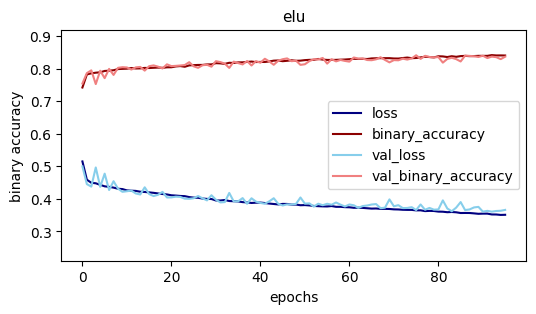

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_elu.history))
ax1.legend(history.history.keys())

ax1.set_title('elu', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.21,0.92)


In [ ]:
print_results(history_elu, cost_elu)

Mejor accuracy de validación 0.841 en época 75 con accuracy de train 0.833
Diferencia error humano y accuracy de train 11.691 %
Diferencia accuracy de train y accuracy de validación -0.837 %
Número de épocas 96
Segundos de ejecución por época 2.251


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_selu = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_selu = time.time() - st

In [ ]:
print_results(history_selu, cost_selu)

Mejor accuracy de validación 0.874 en época 93 con accuracy de train 0.910
Diferencia error humano y accuracy de train 4.047 %
Diferencia accuracy de train y accuracy de validación 3.581 %
Número de épocas 114
Segundos de ejecución por época 1.452


(0.17, 0.96)

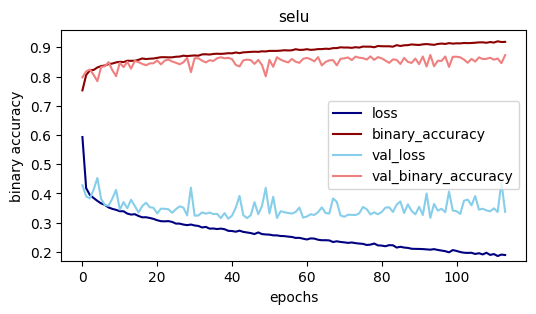

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_selu.history))
ax1.legend(history.history.keys())

ax1.set_title('selu', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.17,0.96)


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(512, activation='softplus'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_softplus = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_softplus = time.time() - st

In [ ]:
print_results(history_softplus, cost_softplus)

Mejor accuracy de validación 0.676 en época 0 con accuracy de train 0.666
Diferencia error humano y accuracy de train 28.406 %
Diferencia accuracy de train y accuracy de validación -0.982 %
Número de épocas 21
Segundos de ejecución por época 2.509


(0.17, 0.96)

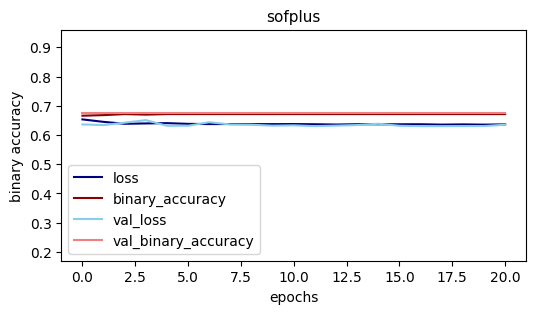

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_softplus.history))
ax1.legend(history.history.keys())

ax1.set_title('sofplus', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.17,0.96)


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_leaky_relu = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_leaky_relu = time.time() - st

In [ ]:
print_results(history_leaky_relu, cost_leaky_relu)

Mejor accuracy de validación 0.870 en época 171 con accuracy de train 0.884
Diferencia error humano y accuracy de train 6.621 %
Diferencia accuracy de train y accuracy de validación 1.392 %
Número de épocas 192
Segundos de ejecución por época 1.842


(0.17, 0.96)

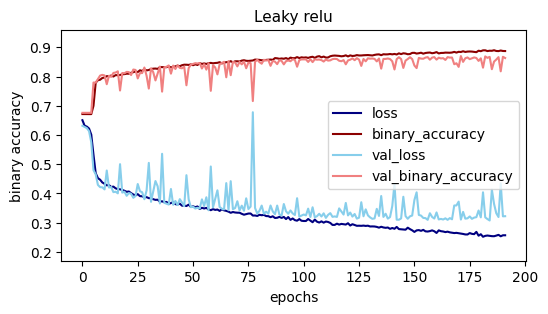

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_leaky_relu.history))
ax1.legend(history.history.keys())

ax1.set_title('Leaky relu', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.17,0.96)


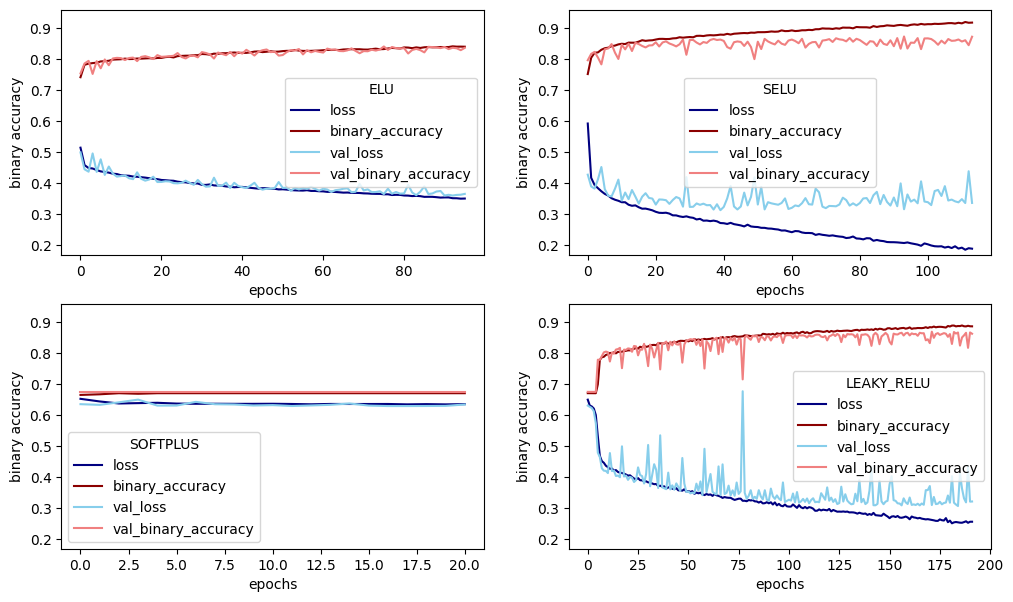

In [ ]:
fig1, ax1 = plt.subplots(2,2, figsize = (12,7))

ax1[0,0].plot(pd.DataFrame(history_elu.history))
ax1[0,0].legend(history_elu.history.keys(), title = 'ELU')
ax1[0,1].plot(pd.DataFrame(history_selu.history))
ax1[0,1].legend(history_selu.history.keys(), title = 'SELU')
ax1[1,0].plot(pd.DataFrame(history_softplus.history))
ax1[1,0].legend(history_softplus.history.keys(), title = 'SOFTPLUS')
ax1[1,1].plot(pd.DataFrame(history_leaky_relu.history))
ax1[1,1].legend(history_leaky_relu.history.keys(), title = 'LEAKY_RELU')
for i in range(2):
  for j in range(2):
    ax1[i,j].set_ylim(0.17,0.96)
    ax1[i,j].set_ylabel('binary accuracy')
    ax1[i,j].set_xlabel('epochs')

## 5. Probar todos los optimizadores

- Adam

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(2048, activation='selu'))
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.Dense(128, activation='selu'))
model.add(keras.layers.Dense(64, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam = time.time() - st

In [ ]:
print_results(history_adam, cost_adam)

Mejor accuracy de validación 0.873 en época 71 con accuracy de train 0.935
Diferencia error humano y accuracy de train 1.479 %
Diferencia accuracy de train y accuracy de validación 6.203 %
Número de épocas 92
Segundos de ejecución por época 1.790


(0.03, 0.98)

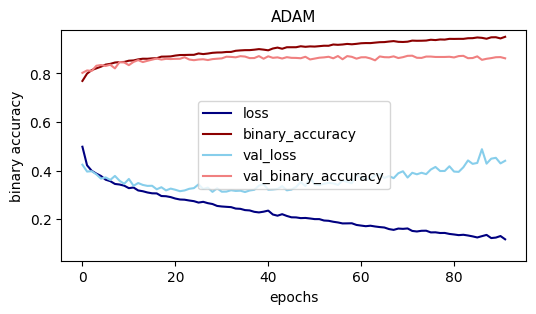

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam.history))
ax1.legend(history.history.keys())

ax1.set_title('ADAM', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='leaky_relu'))
model.add(keras.layers.Dense(2048, activation='leaky_relu'))
model.add(keras.layers.Dense(1024, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(256, activation='leaky_relu'))
model.add(keras.layers.Dense(128, activation='leaky_relu'))
model.add(keras.layers.Dense(64, activation='leaky_relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2 = time.time() - st

In [ ]:
print_results(history_adam2, cost_adam2)

Mejor accuracy de validación 0.877 en época 51 con accuracy de train 0.906
Diferencia error humano y accuracy de train 4.384 %
Diferencia accuracy de train y accuracy de validación 2.940 %
Número de épocas 72
Segundos de ejecución por época 2.227


(0.03, 0.98)

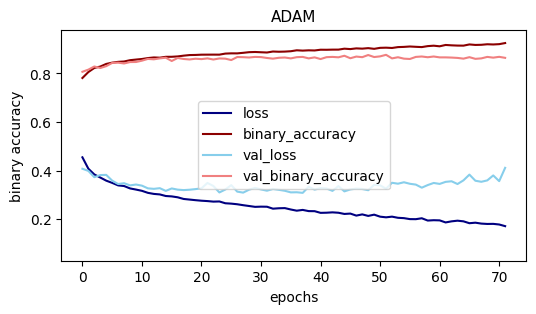

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2.history))
ax1.legend(history.history.keys())

ax1.set_title('ADAM', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='leaky_relu'))
model.add(keras.layers.Dense(2048, activation='leaky_relu'))
model.add(keras.layers.Dense(1024, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(256, activation='leaky_relu'))
model.add(keras.layers.Dense(128, activation='leaky_relu'))
model.add(keras.layers.Dense(64, activation='leaky_relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

epochs = 200
batch_size = 128

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
callback_lrate = Learning_rate_tracker()


model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam4 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb, callback_lrate])

cost_adam4 = time.time() - st

In [ ]:
print_results(history_adam4, cost_adam4)

Mejor accuracy de validación 0.875 en época 66 con accuracy de train 0.914
Diferencia error humano y accuracy de train 3.644 %
Diferencia accuracy de train y accuracy de validación 3.819 %
Número de épocas 87
Segundos de ejecución por época 1.841


(0.03, 0.98)

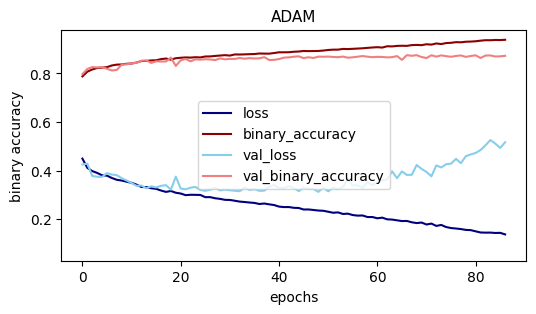

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam4.history))
ax1.legend(history.history.keys())

ax1.set_title('ADAM', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

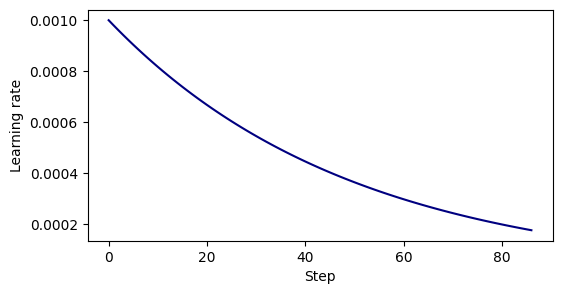

In [ ]:
callback_lrate.plot_lrate()

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam3 = time.time() - st

In [ ]:
print_results(history_adam3, cost_adam3)

Mejor accuracy de validación 0.875 en época 28 con accuracy de train 0.895
Diferencia error humano y accuracy de train 5.474 %
Diferencia accuracy de train y accuracy de validación 1.989 %
Número de épocas 49
Segundos de ejecución por época 3.115


(0.03, 0.98)

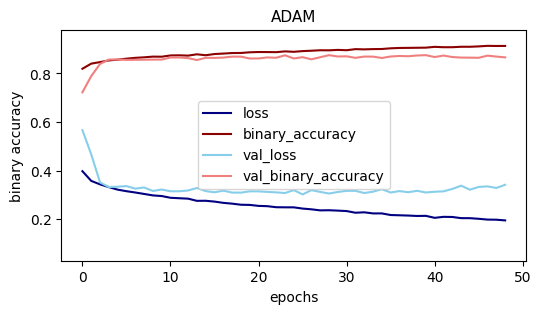

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam3.history))
ax1.legend(history.history.keys())

ax1.set_title('ADAM', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

- Rmsprop

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='leaky_relu'))
model.add(keras.layers.Dense(2048, activation='leaky_relu'))
model.add(keras.layers.Dense(1024, activation='leaky_relu'))
model.add(keras.layers.Dense(512, activation='leaky_relu'))
model.add(keras.layers.Dense(256, activation='leaky_relu'))
model.add(keras.layers.Dense(128, activation='leaky_relu'))
model.add(keras.layers.Dense(64, activation='leaky_relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.RMSprop(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_rmsprop = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_rmsprop = time.time() - st

In [ ]:
print_results(history_rmsprop, cost_rmsprop)

Mejor accuracy de validación 0.871 en época 46 con accuracy de train 0.886
Diferencia error humano y accuracy de train 6.356 %
Diferencia accuracy de train y accuracy de validación 1.547 %
Número de épocas 67
Segundos de ejecución por época 2.254


(0.03, 0.98)

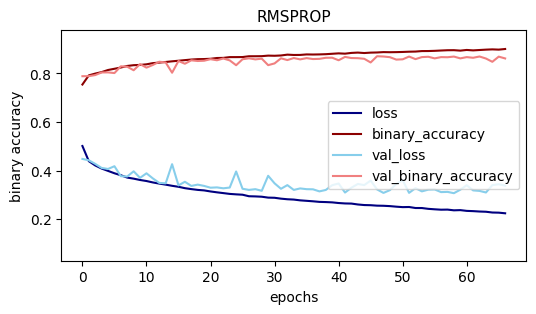

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_rmsprop.history))
ax1.legend(history.history.keys())

ax1.set_title('RMSPROP', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.Dense(64, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.RMSprop(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_rmsprop2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_rmsprop2 = time.time() - st

In [ ]:
print_results(history_rmsprop2, cost_rmsprop2)

Mejor accuracy de validación 0.864 en época 24 con accuracy de train 0.873
Diferencia error humano y accuracy de train 7.662 %
Diferencia accuracy de train y accuracy de validación 0.931 %
Número de épocas 45
Segundos de ejecución por época 3.707


(0.03, 0.98)

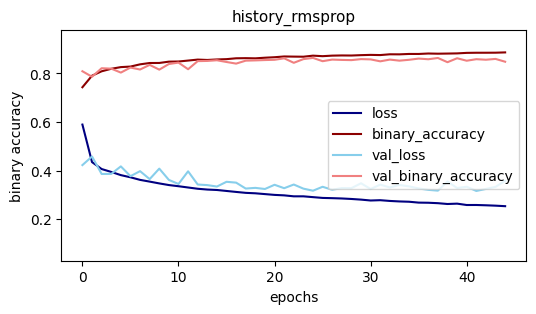

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_rmsprop2.history))
ax1.legend(history.history.keys())

ax1.set_title('history_rmsprop', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.RMSprop(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_rmsprop3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_rmsprop3 = time.time() - st

In [ ]:
print_results(history_rmsprop3, cost_rmsprop3)

Mejor accuracy de validación 0.868 en época 109 con accuracy de train 0.876
Diferencia error humano y accuracy de train 7.366 %
Diferencia accuracy de train y accuracy de validación 0.868 %
Número de épocas 130
Segundos de ejecución por época 1.621


(0.03, 0.98)

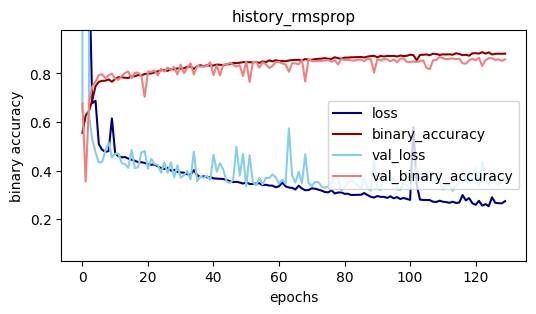

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_rmsprop3.history))
ax1.legend(history.history.keys())

ax1.set_title('history_rmsprop', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.Dense(64, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.RMSprop(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_rmsprop4 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_rmsprop4 = time.time() - st

In [ ]:
print_results(history_rmsprop4, cost_rmsprop4)

Mejor accuracy de validación 0.868 en época 25 con accuracy de train 0.885
Diferencia error humano y accuracy de train 6.532 %
Diferencia accuracy de train y accuracy de validación 1.620 %
Número de épocas 46
Segundos de ejecución por época 3.976


(0.03, 0.98)

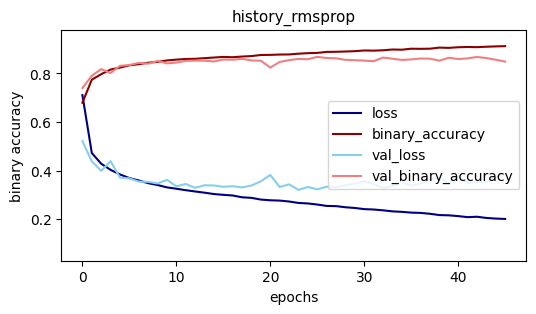

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_rmsprop4.history))
ax1.legend(history.history.keys())

ax1.set_title('history_rmsprop', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

- Momentum

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum = time.time() - st

In [ ]:
print_results(history_momentum, cost_momentum)

Mejor accuracy de validación 0.873 en época 68 con accuracy de train 0.908
Diferencia error humano y accuracy de train 4.216 %
Diferencia accuracy de train y accuracy de validación 3.467 %
Número de épocas 89
Segundos de ejecución por época 1.896


(0.03, 0.98)

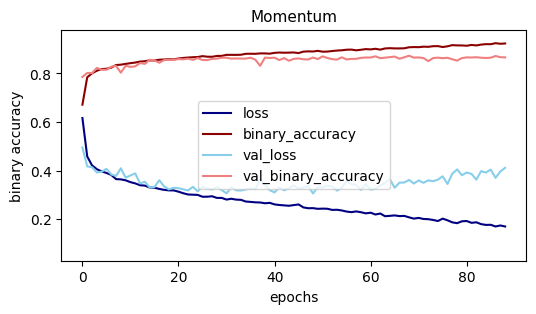

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum2 = time.time() - st

In [ ]:
print_results(history_momentum2, cost_momentum2)

Mejor accuracy de validación 0.869 en época 43 con accuracy de train 0.877
Diferencia error humano y accuracy de train 7.297 %
Diferencia accuracy de train y accuracy de validación 0.800 %
Número de épocas 64
Segundos de ejecución por época 2.351


(0.03, 0.98)

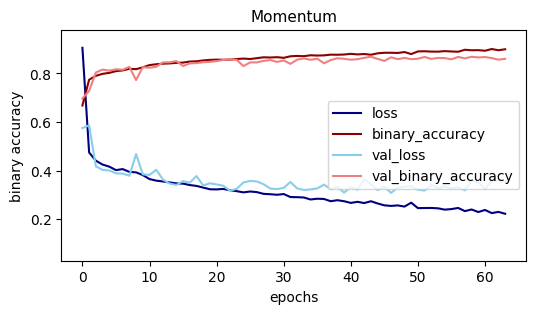

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum2.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='relu'))
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum3 = time.time() - st

In [ ]:
print_results(history_momentum3, cost_momentum3)

Mejor accuracy de validación 0.879 en época 134 con accuracy de train 0.957
Diferencia error humano y accuracy de train -0.744 %
Diferencia accuracy de train y accuracy de validación 7.875 %
Número de épocas 155
Segundos de ejecución por época 1.538


(0.03, 0.98)

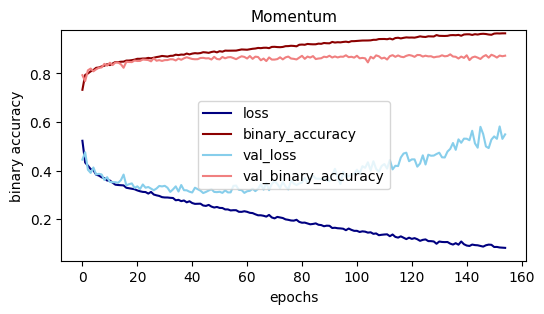

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum3.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

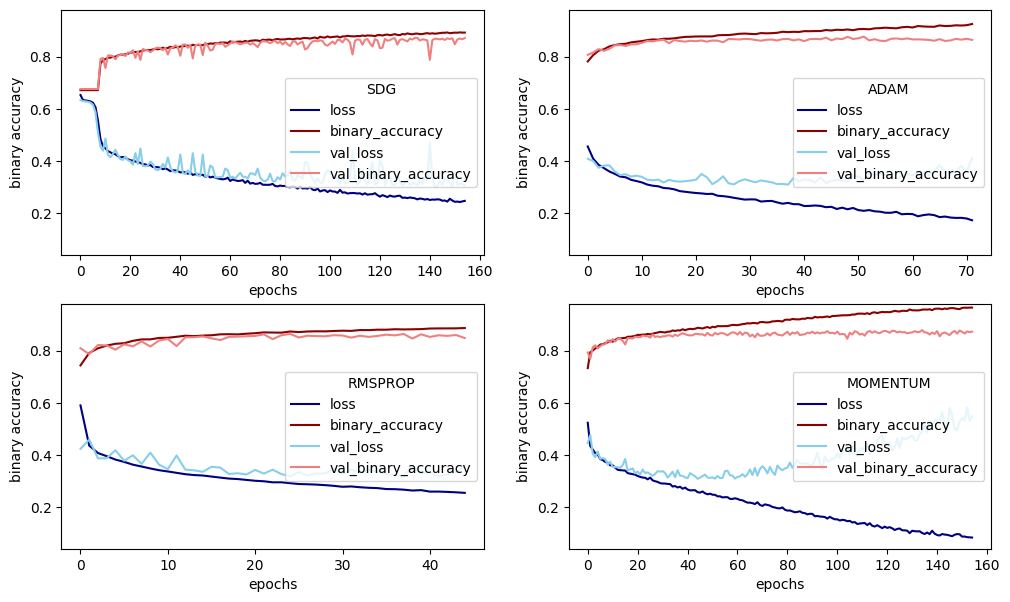

In [ ]:
fig1, ax1 = plt.subplots(2,2, figsize = (12,7))

ax1[0,0].plot(pd.DataFrame(history_aumentando_capas_9.history))
ax1[0,0].legend(history_aumentando_capas_9.history.keys(), title = 'SDG')
ax1[0,1].plot(pd.DataFrame(history_adam2.history))
ax1[0,1].legend(history_adam2.history.keys(), title = 'ADAM')
ax1[1,0].plot(pd.DataFrame(history_rmsprop2.history))
ax1[1,0].legend(history_rmsprop2.history.keys(), title = 'RMSPROP')
ax1[1,1].plot(pd.DataFrame(history_momentum3.history))
ax1[1,1].legend(history_momentum3.history.keys(), title = 'MOMENTUM')
for i in range(2):
  for j in range(2):
    ax1[i,j].set_ylim(0.04,0.98)
    ax1[i,j].set_ylabel('binary accuracy')
    ax1[i,j].set_xlabel('epochs')

- Nesterov

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='relu'))
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, nesterov = True, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_nesterov = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_nesterov = time.time() - st

In [ ]:
print_results(history_nesterov, cost_nesterov)

Mejor accuracy de validación 0.874 en época 77 con accuracy de train 0.920
Diferencia error humano y accuracy de train 2.978 %
Diferencia accuracy de train y accuracy de validación 4.622 %
Número de épocas 98
Segundos de ejecución por época 2.037


(0.03, 0.98)

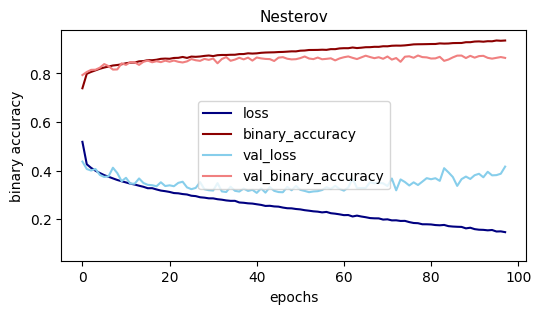

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_nesterov.history))
ax1.legend(history.history.keys())

ax1.set_title('Nesterov', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.Dense(64, activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, nesterov = True, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_nesterov2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_nesterov2 = time.time() - st

In [ ]:
print_results(history_nesterov2, cost_nesterov2)

Mejor accuracy de validación 0.870 en época 64 con accuracy de train 0.897
Diferencia error humano y accuracy de train 5.343 %
Diferencia accuracy de train y accuracy de validación 2.616 %
Número de épocas 85
Segundos de ejecución por época 1.236


(0.03, 0.98)

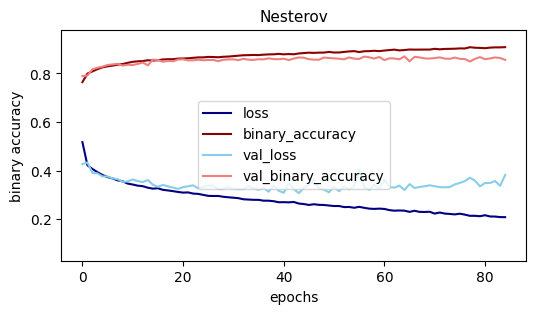

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_nesterov2.history))
ax1.legend(history.history.keys())

ax1.set_title('Nesterov', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

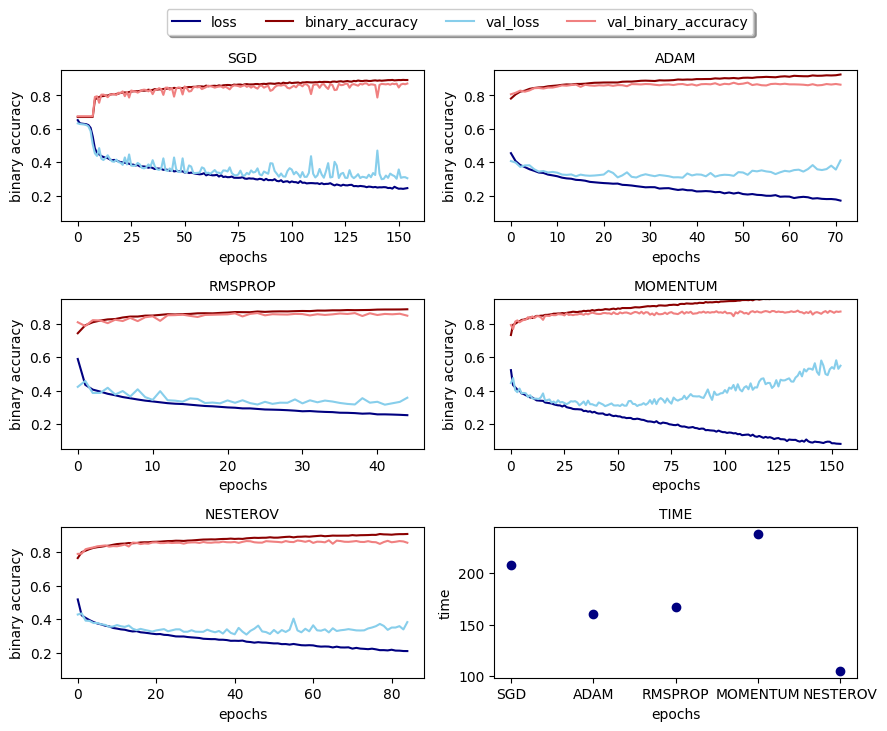

In [ ]:
costes = pd.DataFrame({'SGD':pd.Series(cost_capas_9),
              'ADAM':pd.Series(cost_adam2),
              'RMSPROP':pd.Series(cost_rmsprop2),
              'MOMENTUM':pd.Series(cost_momentum3),
              'NESTEROV':pd.Series(cost_nesterov2)})
costes = costes.T.reset_index()


fig1, ax1 = plt.subplots(3,2, figsize = (9,7))
ax1[0,0].plot(pd.DataFrame(history_aumentando_capas_9.history), label = 'SGD')
ax1[0,1].plot(pd.DataFrame(history_adam2.history), label = 'ADAM')
ax1[1,0].plot(pd.DataFrame(history_rmsprop2.history), label = 'RMSPROP')
ax1[1,1].plot(pd.DataFrame(history_momentum3.history))
ax1[2,0].plot(pd.DataFrame(history_nesterov2.history))
ax1[2,1].scatter(x =costes['index'], y = costes[0])
for i in range(3):
    for j in range(2):
        ax1[i,j].set_xlabel('epochs')
        if (i==2)and(j==1):
            ax1[i,j].set_ylabel('time')
        else:
            ax1[i,j].set_ylabel('binary accuracy')
            ax1[i,j].set_ylim(0.05,0.95)
ax1[0,0].set_title('SGD', fontsize = 10)
ax1[0,1].set_title('ADAM', fontsize = 10)
ax1[1,0].set_title('RMSPROP', fontsize = 10)
ax1[1,1].set_title('MOMENTUM', fontsize = 10)
ax1[2,0].set_title('NESTEROV', fontsize = 10)
ax1[2,1].set_title('TIME', fontsize = 10)

plt.tight_layout()
ax1[0,0].legend(history_aumentando_capas_9.history.keys(), bbox_to_anchor=(1.1, 1.45), loc='upper center',  ncol=6, fancybox=True, shadow=True)




# Reducción de variancia para momentum

BatchNormalization

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum3_bn = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum3_bn = time.time() - st

In [ ]:
print_results(history_momentum3_bn, cost_momentum3_bn)

Mejor accuracy de validación 0.874 en época 21 con accuracy de train 0.900
Diferencia error humano y accuracy de train 4.957 %
Diferencia accuracy de train y accuracy de validación 2.643 %
Número de épocas 42
Segundos de ejecución por época 3.255


(0.03, 0.98)

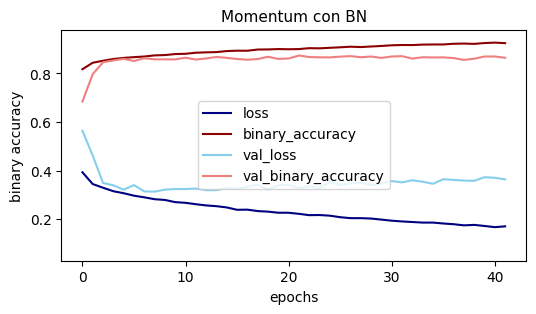

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum3_bn.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum con BN', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(2048))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1024))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(512))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(256))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(64))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum3_bn2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum3_bn2 = time.time() - st

In [ ]:
print_results(history_momentum3_bn2, cost_momentum3_bn2)

Mejor accuracy de validación 0.870 en época 33 con accuracy de train 0.913
Diferencia error humano y accuracy de train 3.723 %
Diferencia accuracy de train y accuracy de validación 4.291 %
Número de épocas 54
Segundos de ejecución por época 3.114


(0.03, 0.98)

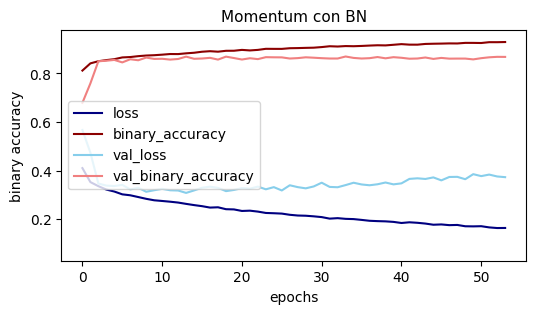

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum3_bn2.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum con BN', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
from keras.initializers import glorot_uniform

st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='relu', kernel_initializer = glorot_uniform()))
model.add(keras.layers.Dense(2048, activation='relu', kernel_initializer = glorot_uniform()))
model.add(keras.layers.Dense(1024, activation='relu', kernel_initializer = glorot_uniform()))
model.add(keras.layers.Dense(512, activation='relu', kernel_initializer = glorot_uniform()))
model.add(keras.layers.Dense(256, activation='relu', kernel_initializer = glorot_uniform()))
model.add(keras.layers.Dense(64, activation='relu', kernel_initializer = glorot_uniform()))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum4 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum4 = time.time() - st

In [ ]:
print_results(history_momentum4, cost_momentum4)

Mejor accuracy de validación 0.870 en época 46 con accuracy de train 0.884
Diferencia error humano y accuracy de train 6.618 %
Diferencia accuracy de train y accuracy de validación 1.341 %
Número de épocas 67
Segundos de ejecución por época 2.066


(0.03, 0.98)

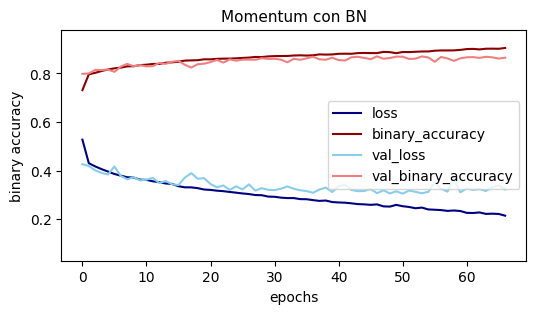

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum4.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum con BN', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
from keras.initializers import he_uniform

st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='relu', kernel_initializer = he_uniform()))
model.add(keras.layers.Dense(2048, activation='relu', kernel_initializer = he_uniform()))
model.add(keras.layers.Dense(1024, activation='relu', kernel_initializer = he_uniform()))
model.add(keras.layers.Dense(512, activation='relu', kernel_initializer = he_uniform()))
model.add(keras.layers.Dense(256, activation='relu', kernel_initializer = he_uniform()))
model.add(keras.layers.Dense(64, activation='relu', kernel_initializer = he_uniform()))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum5 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum5 = time.time() - st

In [ ]:
print_results(history_momentum5, cost_momentum5)

Mejor accuracy de validación 0.871 en época 26 con accuracy de train 0.879
Diferencia error humano y accuracy de train 7.124 %
Diferencia accuracy de train y accuracy de validación 0.751 %
Número de épocas 47
Segundos de ejecución por época 1.844


(0.03, 0.98)

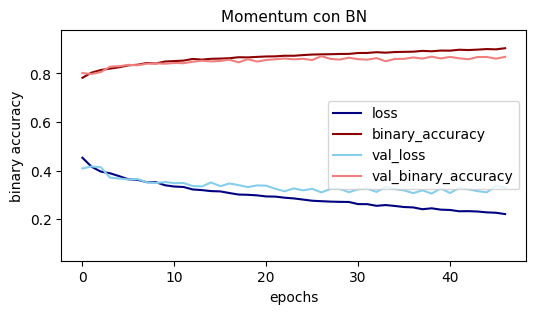

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum5.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum con BN', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum6 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum6 = time.time() - st

In [ ]:
print_results(history_momentum6, cost_momentum6)

Mejor accuracy de validación 0.867 en época 76 con accuracy de train 0.871
Diferencia error humano y accuracy de train 7.931 %
Diferencia accuracy de train y accuracy de validación 0.414 %
Número de épocas 97
Segundos de ejecución por época 2.640


(0.03, 0.98)

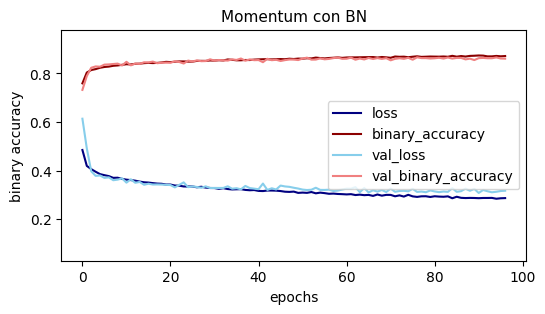

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum6.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum con BN', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(512))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(256))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64))
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum7 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum7 = time.time() - st

In [ ]:
print_results(history_momentum7, cost_momentum7)

Mejor accuracy de validación 0.864 en época 83 con accuracy de train 0.864
Diferencia error humano y accuracy de train 8.634 %
Diferencia accuracy de train y accuracy de validación 0.014 %
Número de épocas 104
Segundos de ejecución por época 2.123


(0.03, 0.98)

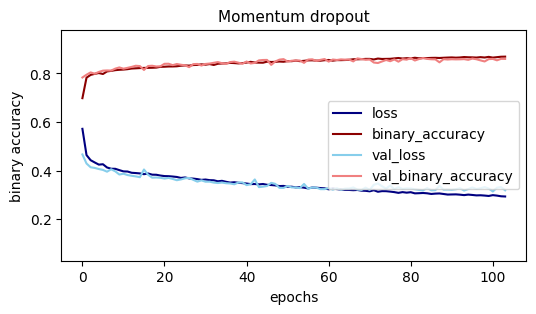

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum7.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum dropout', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
kernel_regularizer='l1'
from keras.initializers import he_uniform

st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='relu', kernel_regularizer = keras.regularizers.L1(0.0001)))
model.add(keras.layers.Dense(2048, activation='relu', kernel_regularizer = keras.regularizers.L1(0.0001)))
model.add(keras.layers.Dense(1024, activation='relu', kernel_regularizer = keras.regularizers.L1(0.0001)))
model.add(keras.layers.Dense(512, activation='relu', kernel_regularizer = keras.regularizers.L1(0.0001)))
model.add(keras.layers.Dense(256, activation='relu', kernel_regularizer = keras.regularizers.L1(0.0001)))
model.add(keras.layers.Dense(64, activation='relu', kernel_regularizer = keras.regularizers.L1(0.0001)))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum8 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum8 = time.time() - st


In [ ]:
print_results(history_momentum8, cost_momentum8)

Mejor accuracy de validación 0.859 en época 70 con accuracy de train 0.851
Diferencia error humano y accuracy de train 9.919 %
Diferencia accuracy de train y accuracy de validación -0.803 %
Número de épocas 91
Segundos de ejecución por época 2.594


(0.03, 0.98)

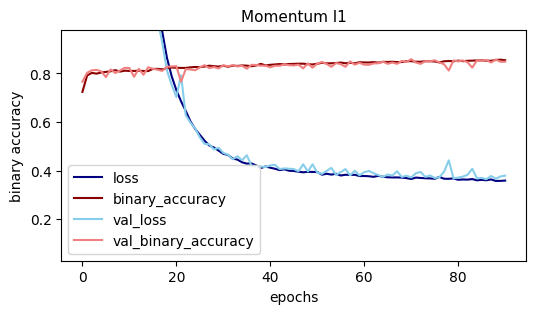

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum8.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum l1', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
from keras.initializers import he_uniform

st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='relu', kernel_regularizer = keras.regularizers.L2(0.0001)))
model.add(keras.layers.Dense(2048, activation='relu', kernel_regularizer = keras.regularizers.L2(0.0001)))
model.add(keras.layers.Dense(1024, activation='relu', kernel_regularizer = keras.regularizers.L2(0.0001)))
model.add(keras.layers.Dense(512, activation='relu', kernel_regularizer = keras.regularizers.L2(0.0001)))
model.add(keras.layers.Dense(256, activation='relu', kernel_regularizer = keras.regularizers.L2(0.0001)))
model.add(keras.layers.Dense(64, activation='relu', kernel_regularizer = keras.regularizers.L2(0.0001)))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum9 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum9 = time.time() - st


In [ ]:
print_results(history_momentum9, cost_momentum9)

Mejor accuracy de validación 0.876 en época 119 con accuracy de train 0.927
Diferencia error humano y accuracy de train 2.282 %
Diferencia accuracy de train y accuracy de validación 5.070 %
Número de épocas 140
Segundos de ejecución por época 2.248


(0.03, 0.98)

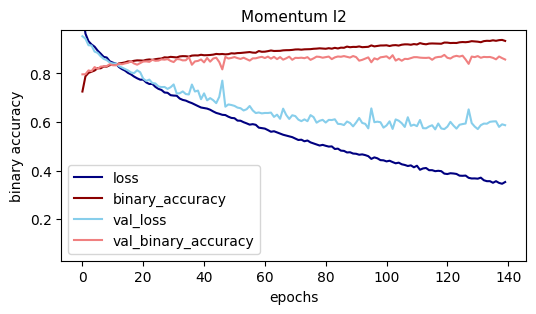

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum9.history))
ax1.legend(history.history.keys())

ax1.set_title('Momentum l2', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum10 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum10 = time.time() - st

In [ ]:
print_results(history_momentum10, cost_momentum10)

Mejor accuracy de validación 0.877 en época 70 con accuracy de train 0.877
Diferencia error humano y accuracy de train 7.266 %
Diferencia accuracy de train y accuracy de validación 0.059 %
Número de épocas 91
Segundos de ejecución por época 3.340


(0.03, 0.98)

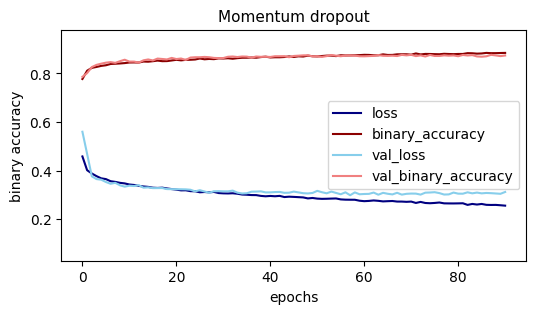

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum10.history))
ax1.legend(history_momentum10.history.keys())

ax1.set_title('Momentum BN + Dropout(0.2)', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.01
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_momentum11 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum11 = time.time() - st

In [ ]:
print_results(history_momentum11, cost_momentum11)

Mejor accuracy de validación 0.880 en época 59 con accuracy de train 0.886
Diferencia error humano y accuracy de train 6.421 %
Diferencia accuracy de train y accuracy de validación 0.572 %
Número de épocas 80
Segundos de ejecución por época 4.030


(0.03, 0.98)

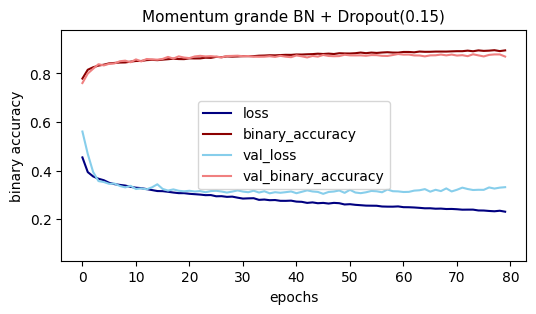

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum11.history))
ax1.legend(history_momentum11.history.keys())

ax1.set_title('Momentum grande BN + Dropout(0.15)', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()
model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.05, initial_bs=128, decay_rate=0.98, staircase=True)

epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.SGD(momentum = 0.9, learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_momentum12 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_momentum12 = time.time() - st

In [ ]:
print_results(history_momentum12, cost_momentum12)

Mejor accuracy de validación 0.878 en época 56 con accuracy de train 0.895
Diferencia error humano y accuracy de train 5.536 %
Diferencia accuracy de train y accuracy de validación 1.678 %
Número de épocas 77
Segundos de ejecución por época 4.247


(0.03, 0.98)

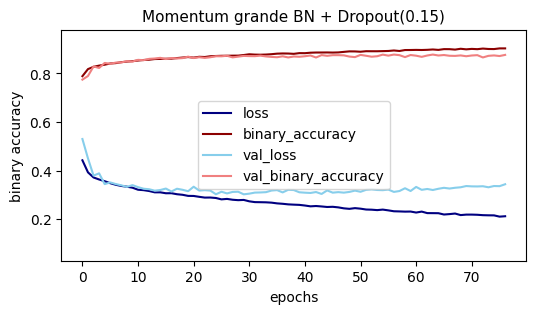

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_momentum12.history))
ax1.legend(history_momentum12.history.keys())

ax1.set_title('Momentum grande BN + Dropout(0.15) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
'''
history_momentum3_bn #batch antes
history_momentum3_bn2 #batch despues
history_momentum4 #glorot initializer
history_momentum5 #he initializer
history_momentum6 #batch + dropout
history_momentum7 #dropout
history_momentum8 #L1
history_momentum9 #L2
'''

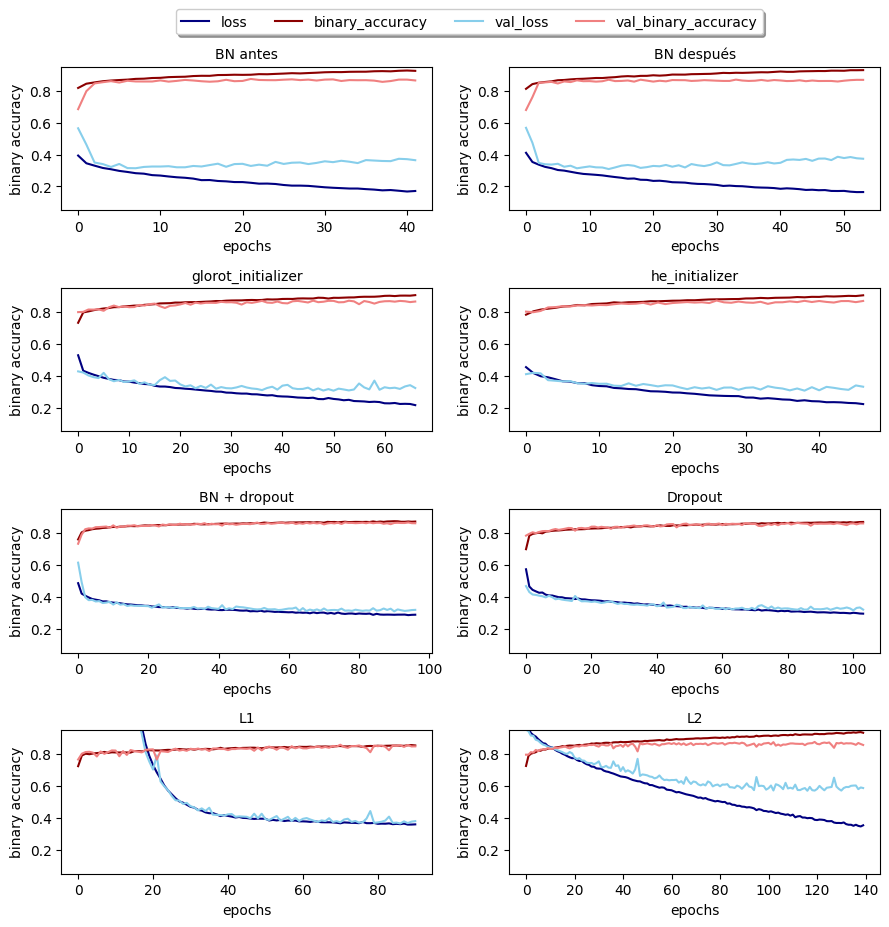

In [ ]:
fig1, ax1 = plt.subplots(4,2, figsize = (9,9))
ax1[0,0].plot(pd.DataFrame(history_momentum3_bn.history), label = 'BN antes')
ax1[0,1].plot(pd.DataFrame(history_momentum3_bn2.history), label = 'BN después')
ax1[1,0].plot(pd.DataFrame(history_momentum4.history), label = 'Xavier_initializer')
ax1[1,1].plot(pd.DataFrame(history_momentum5.history), label = 'he_initializer')
ax1[2,0].plot(pd.DataFrame(history_momentum6.history), label = 'BN + dropout')
ax1[2,1].plot(pd.DataFrame(history_momentum7.history), label = 'Dropout')
ax1[3,0].plot(pd.DataFrame(history_momentum8.history), label = 'L1')
ax1[3,1].plot(pd.DataFrame(history_momentum9.history), label = 'L2')

for i in range(4):
    for j in range(2):
        ax1[i,j].set_xlabel('epochs')
        ax1[i,j].set_ylabel('binary accuracy')
        ax1[i,j].set_ylim(0.05,0.95)

ax1[0,0].set_title('BN antes', fontsize = 10)
ax1[0,1].set_title('BN después', fontsize = 10)
ax1[1,0].set_title('glorot_initializer', fontsize = 10)
ax1[1,1].set_title('he_initializer', fontsize = 10)
ax1[2,0].set_title('BN + dropout', fontsize = 10)
ax1[2,1].set_title('Dropout', fontsize = 10)
ax1[3,0].set_title('L1', fontsize = 10)
ax1[3,1].set_title('L2', fontsize = 10)

plt.tight_layout()
ax1[0,0].legend(history_aumentando_capas_9.history.keys(), bbox_to_anchor=(1.1, 1.45), loc='upper center',  ncol=6, fancybox=True, shadow=True)




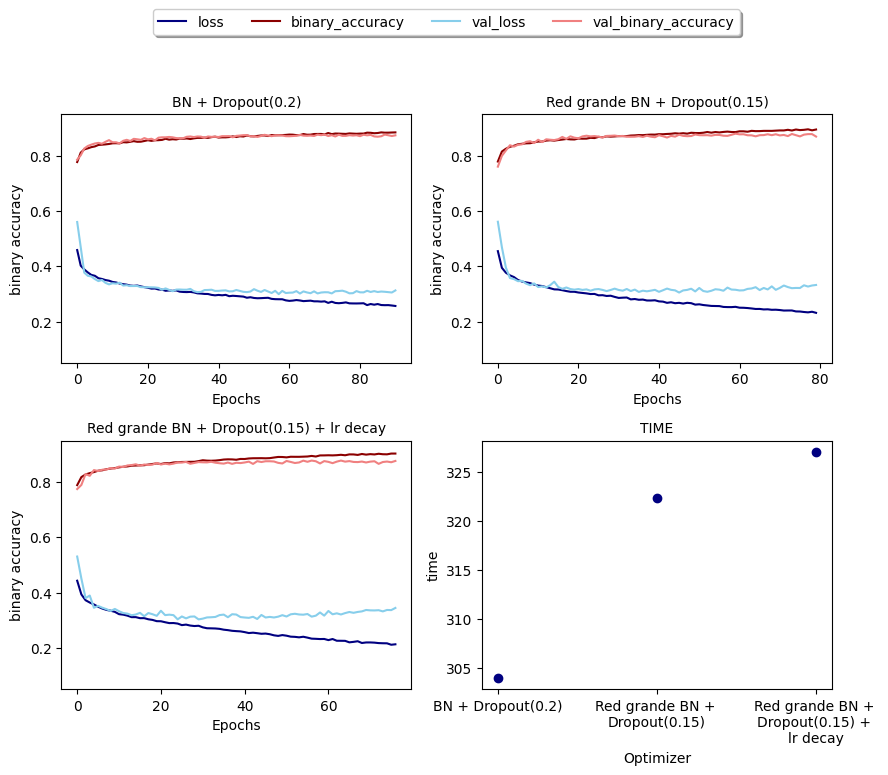

In [ ]:
costes = pd.DataFrame({'BN + Dropout(0.2)':pd.Series(cost_momentum10),
              'Red grande BN + \nDropout(0.15)':pd.Series(cost_momentum11),
              'Red grande BN + \nDropout(0.15) + \nlr decay':pd.Series(cost_momentum12)})
costes = costes.T.reset_index()


fig1, ax1 = plt.subplots(2,2, figsize = (9,7))
ax1[0,0].plot(pd.DataFrame(history_momentum10.history), label = 'BN + Dropout(0.2)')
ax1[0,1].plot(pd.DataFrame(history_momentum11.history), label = 'Red grande BN + Dropout(0.15)')
ax1[1,0].plot(pd.DataFrame(history_momentum12.history), label = 'Red grande BN + Dropout(0.15) + lr decay')
ax1[1,1].scatter(x =costes['index'], y = costes[0])
for i in range(2):
    for j in range(2):

        if (i==1)and(j==1):
            ax1[i,j].set_xlabel('Optimizer')
            ax1[i,j].set_ylabel('time')
        else:
            ax1[i,j].set_xlabel('Epochs')
            ax1[i,j].set_ylabel('binary accuracy')
            ax1[i,j].set_ylim(0.05,0.95)
ax1[0,0].set_title('BN + Dropout(0.2)', fontsize = 10)
ax1[0,1].set_title('Red grande BN + Dropout(0.15)', fontsize = 10)
ax1[1,0].set_title('Red grande BN + Dropout(0.15) + lr decay', fontsize = 10)
ax1[1,1].set_title('TIME', fontsize = 10)

plt.tight_layout()
ax1[0,0].legend(history_momentum10.history.keys(), bbox_to_anchor=(1.1, 1.45), loc='upper center',  ncol=6, fancybox=True, shadow=True)

# Reducción de variancia para Adam

BatchNormalization

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))


early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate),
              metrics = 'binary_accuracy')


history_adam2_bn = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn = time.time() - st

In [ ]:
print_results(history_adam2_bn, cost_adam2_bn)

Mejor accuracy de validación 0.877 en época 55 con accuracy de train 0.919
Diferencia error humano y accuracy de train 3.096 %
Diferencia accuracy de train y accuracy de validación 4.229 %
Número de épocas 76
Segundos de ejecución por época 3.586


(0.03, 0.98)

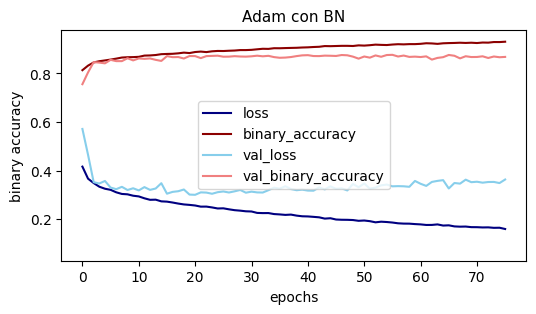

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn.history))
ax1.legend(history_adam2_bn.history.keys())

ax1.set_title('Adam con BN', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam2_bn2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn2 = time.time() - st

In [ ]:
print_results(history_adam2_bn2, cost_adam2_bn2)

Mejor accuracy de validación 0.867 en época 62 con accuracy de train 0.866
Diferencia error humano y accuracy de train 8.448 %
Diferencia accuracy de train y accuracy de validación -0.186 %
Número de épocas 83
Segundos de ejecución por época 3.473


(0.03, 0.98)

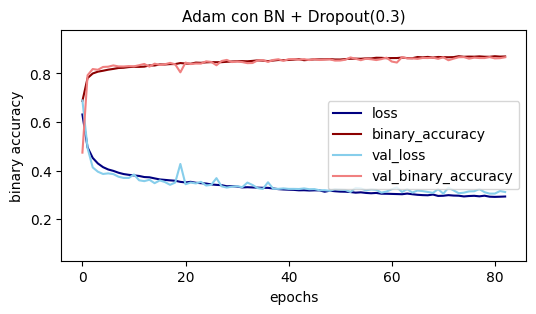

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn2.history))
ax1.legend(history_adam2_bn2.history.keys())

ax1.set_title('Adam con BN + Dropout(0.3)', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam2_bn3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn3 = time.time() - st

In [ ]:
print_results(history_adam2_bn3, cost_adam2_bn3)

Mejor accuracy de validación 0.873 en época 56 con accuracy de train 0.868
Diferencia error humano y accuracy de train 8.175 %
Diferencia accuracy de train y accuracy de validación -0.493 %
Número de épocas 77
Segundos de ejecución por época 5.742


(0.03, 0.98)

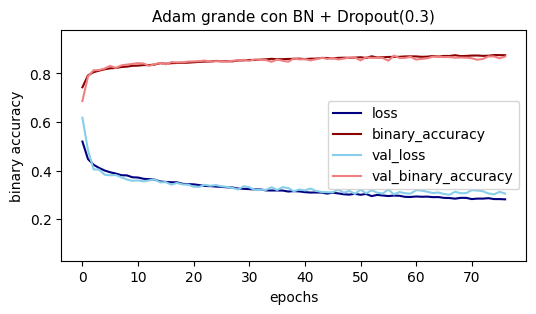

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn3.history))
ax1.legend(history_adam2_bn2.history.keys())

ax1.set_title('Adam grande con BN + Dropout(0.3)', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.0001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam2_bn4 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn4 = time.time() - st

In [ ]:
print_results(history_adam2_bn4, cost_adam2_bn4)

Mejor accuracy de validación 0.879 en época 96 con accuracy de train 0.892
Diferencia error humano y accuracy de train 5.773 %
Diferencia accuracy de train y accuracy de validación 1.330 %
Número de épocas 117
Segundos de ejecución por época 5.346


(0.03, 0.98)

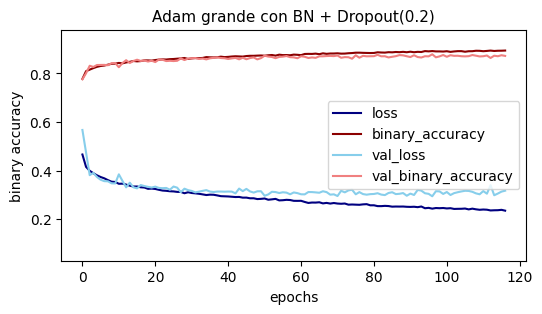

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn4.history))
ax1.legend(history_adam2_bn4.history.keys())

ax1.set_title('Adam grande con BN + Dropout(0.2)', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn5 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn5 = time.time() - st

In [ ]:
print_results(history_adam2_bn5, cost_adam2_bn5)

Mejor accuracy de validación 0.886 en época 97 con accuracy de train 0.901
Diferencia error humano y accuracy de train 4.919 %
Diferencia accuracy de train y accuracy de validación 1.468 %
Número de épocas 118
Segundos de ejecución por época 5.388


(0.03, 0.98)

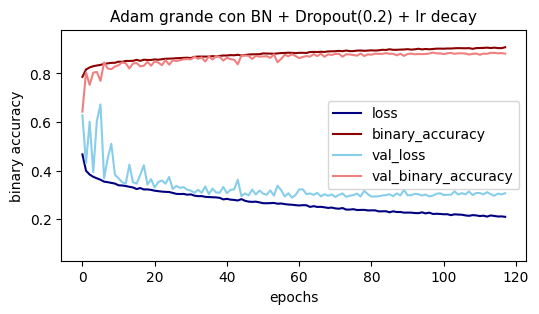

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn5.history))
ax1.legend(history_adam2_bn5.history.keys())

ax1.set_title('Adam grande con BN + Dropout(0.2) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.15))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn6 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn6 = time.time() - st

In [ ]:
print_results(history_adam2_bn6, cost_adam2_bn6)

Mejor accuracy de validación 0.885 en época 65 con accuracy de train 0.889
Diferencia error humano y accuracy de train 6.056 %
Diferencia accuracy de train y accuracy de validación 0.469 %
Número de épocas 86
Segundos de ejecución por época 6.234


(0.03, 0.98)

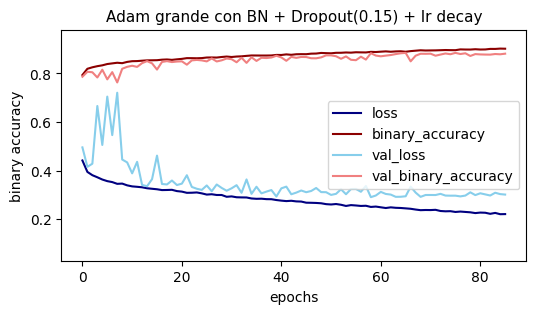

In [ ]:

fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn6.history))
ax1.legend(history_adam2_bn6.history.keys())

ax1.set_title('Adam grande con BN + Dropout(0.15) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
'''
history_momentum3_bn #batch antes
history_momentum3_bn2 #batch despues
history_momentum4 #glorot initializer
history_momentum5 #he initializer
history_momentum6 #batc + dropout
history_momentum7 #dropout
history_momentum8 #L1
history_momentum9 #L2
'''

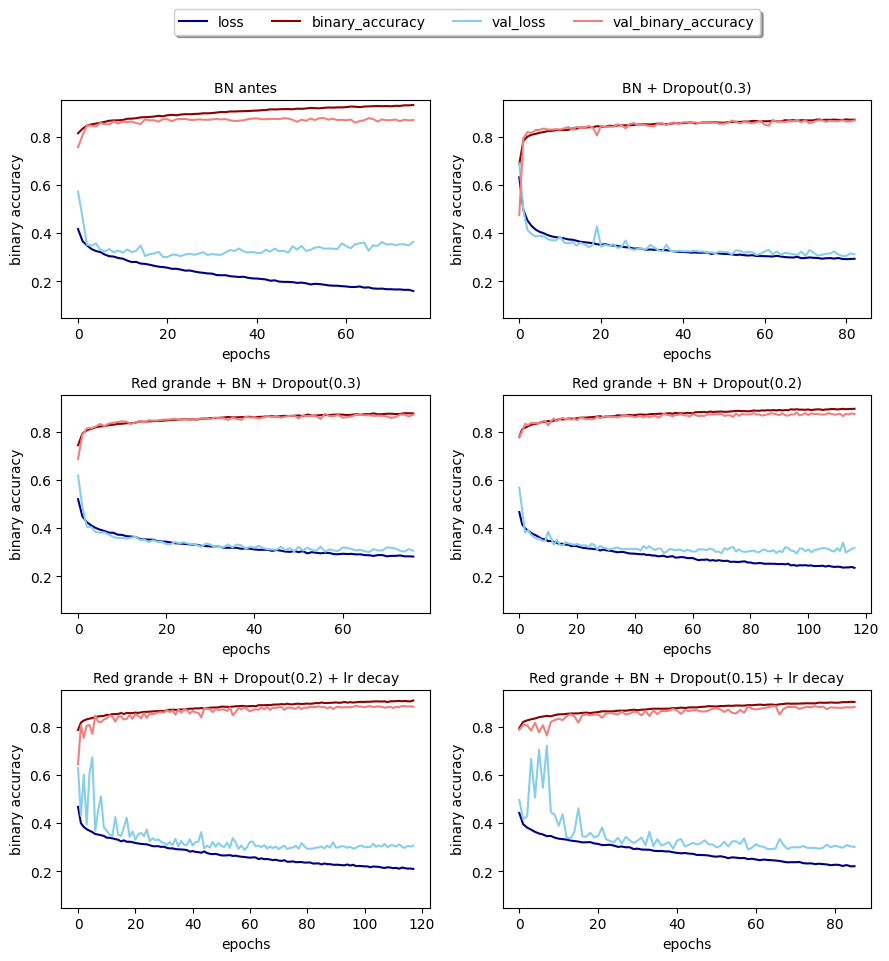

In [ ]:
fig1, ax1 = plt.subplots(3,2, figsize = (9,9))
ax1[0,0].plot(pd.DataFrame(history_adam2_bn.history), label = 'BN antes')
ax1[0,1].plot(pd.DataFrame(history_adam2_bn2.history), label = 'BN + Dropout(0.3)')
ax1[1,0].plot(pd.DataFrame(history_adam2_bn3.history), label = 'Red grande + BN + Dropout(0.3)')
ax1[1,1].plot(pd.DataFrame(history_adam2_bn4.history), label = 'Red grande + BN + Dropout(0.2)')
ax1[2,0].plot(pd.DataFrame(history_adam2_bn5.history), label = 'Red grande + BN + Dropout(0.2) + lr decay')
ax1[2,1].plot(pd.DataFrame(history_adam2_bn6.history), label = 'Red grande + BN + Dropout(0.15) + lr decay')

for i in range(3):
    for j in range(2):
        ax1[i,j].set_xlabel('epochs')
        ax1[i,j].set_ylabel('binary accuracy')
        ax1[i,j].set_ylim(0.05,0.95)

ax1[0,0].set_title('BN antes', fontsize = 10)
ax1[0,1].set_title('BN + Dropout(0.3)', fontsize = 10)
ax1[1,0].set_title('Red grande + BN + Dropout(0.3)', fontsize = 10)
ax1[1,1].set_title('Red grande + BN + Dropout(0.2)', fontsize = 10)
ax1[2,0].set_title('Red grande + BN + Dropout(0.2) + lr decay', fontsize = 10)
ax1[2,1].set_title('Red grande + BN + Dropout(0.15) + lr decay', fontsize = 10)

plt.tight_layout()
ax1[0,0].legend(history_adam2_bn6.history.keys(), bbox_to_anchor=(1.1, 1.45), loc='upper center',  ncol=6, fancybox=True, shadow=True)




Text(0, 0.5, 'Time')

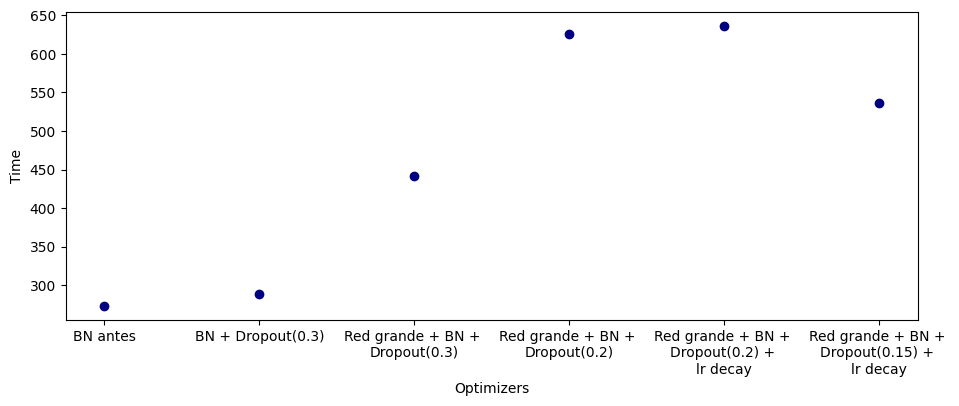

In [ ]:
costes_adam = pd.DataFrame({'BN antes':pd.Series(cost_adam2_bn),
              'BN + Dropout(0.3)':pd.Series(cost_adam2_bn2),
              'Red grande + BN + \nDropout(0.3)':pd.Series(cost_adam2_bn3),
              'Red grande + BN + \nDropout(0.2)':pd.Series(cost_adam2_bn4),
              'Red grande + BN + \nDropout(0.2) + \nlr decay':pd.Series(cost_adam2_bn5),
              'Red grande + BN + \nDropout(0.15) + \nlr decay':pd.Series(cost_adam2_bn6)})
costes_adam = costes_adam.T.reset_index()

plt.figure(figsize=(11, 4))
plt.scatter(x=costes_adam['index'], y = costes_adam[0])
plt.xlabel('Optimizers')
plt.ylabel('Time')




In [ ]:
st = time.time()

model0 = keras.models.Sequential()
model0.add(keras.layers.Dense(4096))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(4096))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(4096))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(2048))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(2048))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(2048))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(1024))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(512))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(256))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(128))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(64))
model0.add(keras.layers.BatchNormalization())
model0.add(keras.layers.Activation('leaky_relu'))
model0.add(keras.layers.Dropout(0.15))
model0.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 30, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model0.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn7 = model0.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn7 = time.time() - st

In [ ]:
print_results(history_adam2_bn7, cost_adam2_bn7)

Mejor accuracy de validación 0.891 en época 140 con accuracy de train 0.922
Diferencia error humano y accuracy de train 2.775 %
Diferencia accuracy de train y accuracy de validación 3.116 %
Número de épocas 171
Segundos de ejecución por época 7.112


(0.03, 0.98)

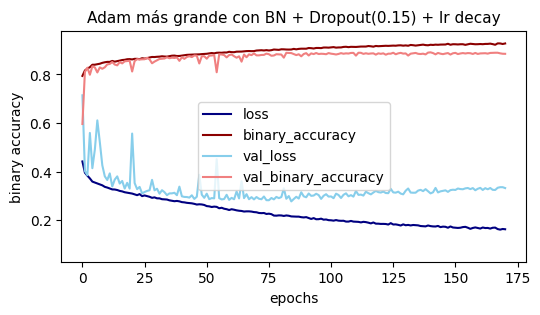

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn7.history))
ax1.legend(history_adam2_bn7.history.keys())

ax1.set_title('Adam más grande con BN + Dropout(0.15) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations = model0.evaluate(x=X_test, y=y_test, return_dict=True)

114/114 [==============================] - 0s 4ms/step - loss: 0.3801 - binary_accuracy: 0.8660


In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('leaky_relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 30, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn8 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn8 = time.time() - st

In [ ]:
print_results(history_adam2_bn8, cost_adam2_bn8)

Mejor accuracy de validación 0.891 en época 139 con accuracy de train 0.915
Diferencia error humano y accuracy de train 3.537 %
Diferencia accuracy de train y accuracy de validación 2.381 %
Número de épocas 170
Segundos de ejecución por época 6.724


(0.03, 0.98)

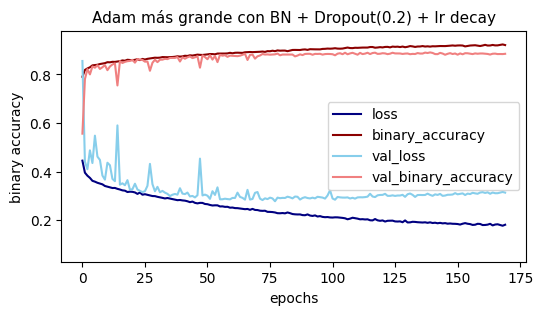

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn8.history))
ax1.legend(history_adam2_bn8.history.keys())

ax1.set_title('Adam más grande con BN + Dropout(0.2) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations = model.evaluate(x=X_test, y=y_test, return_dict=True)
print(evaluations)

114/114 [==============================] - 0s 4ms/step - loss: 0.3706 - binary_accuracy: 0.8621
{'loss': 0.37062257528305054, 'binary_accuracy': 0.8621450066566467}


In [ ]:
st = time.time()

model2 = keras.models.Sequential()
model2.add(keras.layers.Dense(4096))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(4096))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(4096))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(2048))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(2048))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(2048))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(1024))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(1024))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(512))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(512))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(256))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(128))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2))
model2.add(keras.layers.Dense(64))
model2.add(keras.layers.BatchNormalization())
model2.add(keras.layers.Activation('leaky_relu'))
model2.add(keras.layers.Dropout(0.2 ))
model2.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 30, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model2.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule),
              metrics = 'binary_accuracy')


history_adam2_bn9 = model2.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn9 = time.time() - st

In [ ]:
print_results(history_adam2_bn9, cost_adam2_bn9)

Mejor accuracy de validación 0.890 en época 126 con accuracy de train 0.913
Diferencia error humano y accuracy de train 3.699 %
Diferencia accuracy de train y accuracy de validación 2.330 %
Número de épocas 157
Segundos de ejecución por época 7.067


(0.03, 0.98)

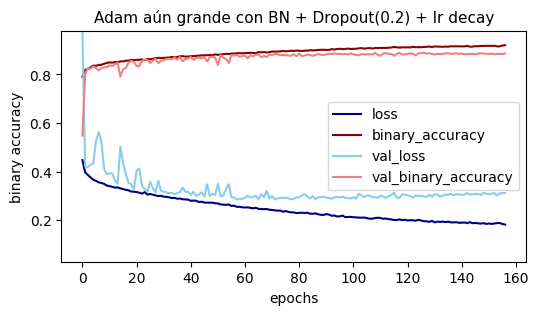

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn9.history))
ax1.legend(history_adam2_bn9.history.keys())

ax1.set_title('Adam aún grande con BN + Dropout(0.2) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations = model2.evaluate(x=X_test, y=y_test, return_dict=True)
print(evaluations)

114/114 [==============================] - 1s 5ms/step - loss: 0.3632 - binary_accuracy: 0.8655
{'loss': 0.36318349838256836, 'binary_accuracy': 0.8654535412788391}


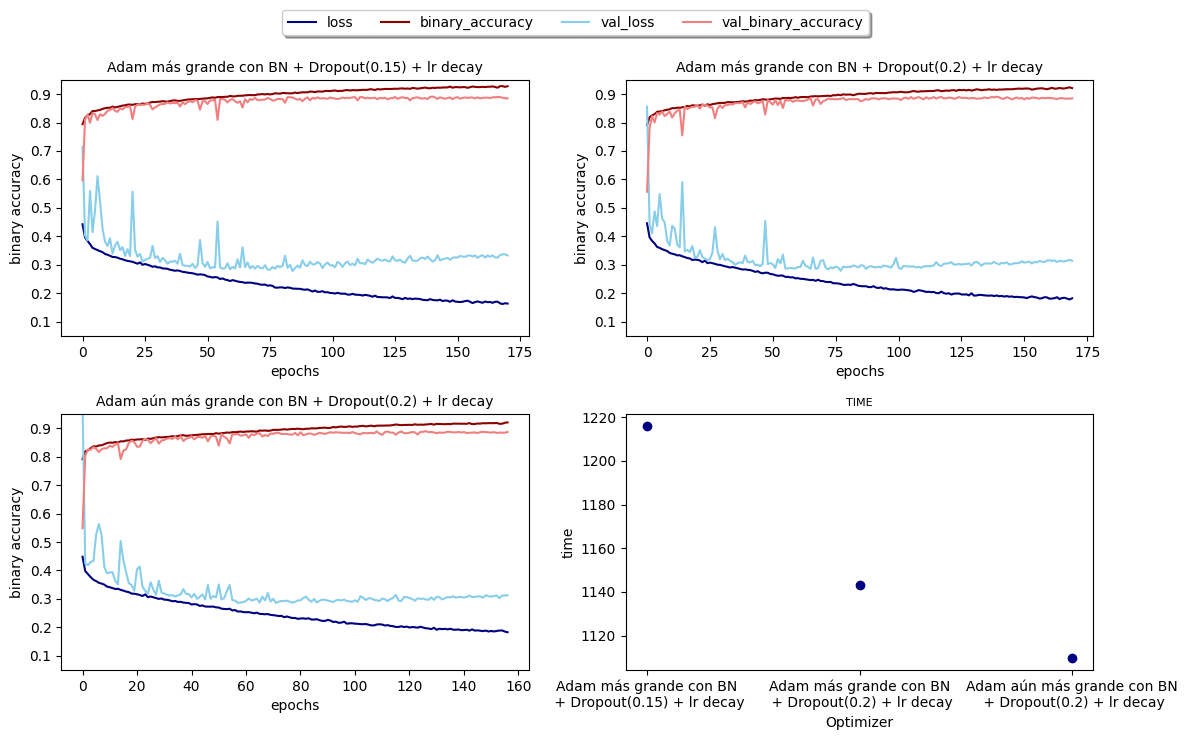

In [ ]:
costes_finales = pd.DataFrame({
              'Adam más grande con BN\n + Dropout(0.15) + lr decay':pd.Series(cost_adam2_bn7),
              'Adam más grande con BN\n + Dropout(0.2) + lr decay':pd.Series(cost_adam2_bn8),
              'Adam aún más grande con BN\n + Dropout(0.2) + lr decay':pd.Series(cost_adam2_bn9),
              })
costes_finales = costes_finales.T.reset_index()

fig1, ax1 = plt.subplots(2,2, figsize = (12,7))

ax1[0,0].plot(pd.DataFrame(history_adam2_bn7.history), label = 'Adam más grande con BN + Dropout(0.15) + lr decay')
ax1[0,1].plot(pd.DataFrame(history_adam2_bn8.history), label = 'Adam más grande con BN + Dropout(0.2) + lr decay')
ax1[1,0].plot(pd.DataFrame(history_adam2_bn9.history), label = 'Adam aún más grande con BN + Dropout(0.2) + lr decay')
ax1[1,1].scatter(x= costes_finales['index'], y = costes_finales[0])

for i in range(2):
    for j in range(2):
      if (i==1)and(j==1):
            ax1[i,j].set_xlabel('Optimizer')
            ax1[i,j].set_ylabel('time')
      else:
          ax1[i,j].set_xlabel('epochs')
          ax1[i,j].set_ylabel('binary accuracy')
          ax1[i,j].set_ylim(0.05,0.95)

ax1[0,0].set_title('Adam más grande con BN + Dropout(0.15) + lr decay', fontsize = 10)
ax1[0,1].set_title('Adam más grande con BN + Dropout(0.2) + lr decay', fontsize = 10)
ax1[1,0].set_title('Adam aún más grande con BN + Dropout(0.2) + lr decay', fontsize = 10)
ax1[1,1].set_title('TIME', fontsize = 8)

plt.tight_layout()
ax1[0,0].legend(history_adam2_bn8.history.keys(), bbox_to_anchor=(1.1, 1.3), loc='upper center',  ncol=6, fancybox=True, shadow=True)


In [ ]:
from sklearn.metrics import confusion_matrix

print('Evaluación Modelo Adam más grande con BN + Dropout(0.15) + lr decay')
final_evaluation0 = model0.evaluate(x=X_test, y=y_test, return_dict=True)

print('\nAdam más grande con BN + Dropout(0.2) + lr decay')
final_evaluation = model.evaluate(x=X_test, y=y_test, return_dict=True)

print('\nAdam aún más grande con BN + Dropout(0.2) + lr decay')
final_evaluation = model2.evaluate(x=X_test, y=y_test, return_dict=True)

print('\n\nMatriz de confusión de las predicciones del modelo 0')
y_prediction0 = model0.predict(X_test)
result0 = confusion_matrix(y_test, y_prediction0.round())
print(result0)

print('\nMatriz de confusión de las predicciones del modelo')
y_prediction = model.predict(X_test)
result = confusion_matrix(y_test, y_prediction.round())
print(result)

print('\nMatriz de confusión de las predicciones del modelo 2')
y_prediction2 = model2.predict(X_test)
result2 = confusion_matrix(y_test, y_prediction2.round())
print(result2)

Evaluación Modelo Adam más grande con BN + Dropout(0.15) + lr decay
114/114 [==============================] - 1s 7ms/step - loss: 0.3801 - binary_accuracy: 0.8660

Adam más grande con BN + Dropout(0.2) + lr decay
114/114 [==============================] - 1s 6ms/step - loss: 0.3706 - binary_accuracy: 0.8621

Adam aún más grande con BN + Dropout(0.2) + lr decay
114/114 [==============================] - 1s 7ms/step - loss: 0.3632 - binary_accuracy: 0.8655


Matriz de confusión de las predicciones del modelo 0
114/114 [==============================] - 1s 4ms/step
[[ 871  290]
 [ 196 2270]]

Matriz de confusión de las predicciones del modelo 0
114/114 [==============================] - 0s 4ms/step
[[ 870  291]
 [ 209 2257]]

Matriz de confusión de las predicciones del modelo 0
114/114 [==============================] - 1s 4ms/step
[[ 873  288]
 [ 200 2266]]


In [ ]:
st = time.time()

model3 = keras.models.Sequential()
model3.add(keras.layers.Dense(4096))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(4096))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(4096))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(2048))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(2048))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(2048))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(1024))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(512))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(256))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(128))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(64))
model3.add(keras.layers.BatchNormalization())
model3.add(keras.layers.Activation('leaky_relu'))
model3.add(keras.layers.Dropout(0.15))
model3.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model3.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn10 = model3.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn10 = time.time() - st

In [ ]:
print_results(history_adam2_bn10, cost_adam2_bn10)

Mejor accuracy de validación 0.891 en época 108 con accuracy de train 0.914
Diferencia error humano y accuracy de train 3.578 %
Diferencia accuracy de train y accuracy de validación 2.285 %
Número de épocas 129
Segundos de ejecución por época 7.175


(0.03, 0.98)

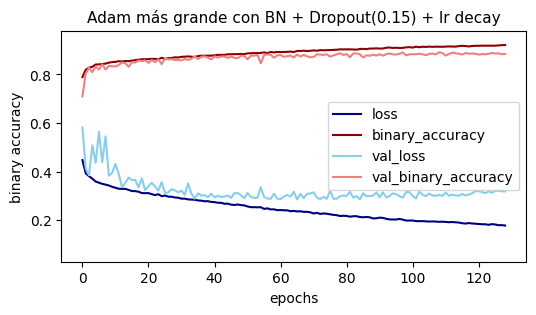

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn10.history))
ax1.legend(history_adam2_bn10.history.keys())

ax1.set_title('Adam más grande con BN + Dropout(0.15) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations3 = model3.evaluate(x=X_test, y=y_test, return_dict=True)

114/114 [==============================] - 1s 7ms/step - loss: 0.3718 - binary_accuracy: 0.8693


In [ ]:
st = time.time()

model4 = keras.models.Sequential()
model4.add(keras.layers.Dense(4096))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(4096))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(4096))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(2048))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(2048))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(2048))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(1024))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(512))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(256))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(128))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(64))
model4.add(keras.layers.BatchNormalization())
model4.add(keras.layers.Activation('leaky_relu'))
model4.add(keras.layers.Dropout(0.2))
model4.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model4.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn11 = model4.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn11 = time.time() - st

In [ ]:
print_results(history_adam2_bn11, cost_adam2_bn11)

Mejor accuracy de validación 0.884 en época 62 con accuracy de train 0.889
Diferencia error humano y accuracy de train 6.084 %
Diferencia accuracy de train y accuracy de validación 0.469 %
Número de épocas 83
Segundos de ejecución por época 6.666


(0.03, 0.98)

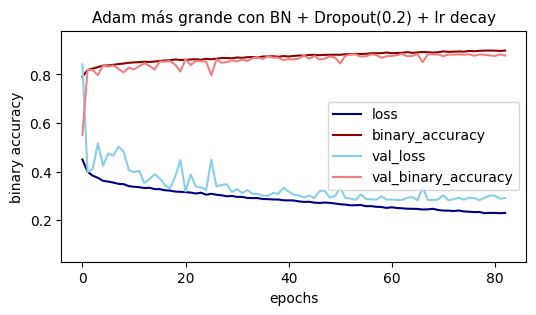

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn11.history))
ax1.legend(history_adam2_bn11.history.keys())

ax1.set_title('Adam más grande con BN + Dropout(0.2) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations4 = model4.evaluate(x=X_test, y=y_test, return_dict=True)

114/114 [==============================] - 1s 6ms/step - loss: 0.3296 - binary_accuracy: 0.8641


In [ ]:
st = time.time()

model5 = keras.models.Sequential()
model5.add(keras.layers.Dense(4096))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(4096))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(4096))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(2048))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(2048))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(2048))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(1024))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(1024))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(512))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(512))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(256))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(128))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2))
model5.add(keras.layers.Dense(64))
model5.add(keras.layers.BatchNormalization())
model5.add(keras.layers.Activation('leaky_relu'))
model5.add(keras.layers.Dropout(0.2 ))
model5.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model5.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule),
              metrics = 'binary_accuracy')


history_adam2_bn12 = model5.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn12 = time.time() - st

In [ ]:
print_results(history_adam2_bn12, cost_adam2_bn12)

Mejor accuracy de validación 0.886 en época 56 con accuracy de train 0.885
Diferencia error humano y accuracy de train 6.452 %
Diferencia accuracy de train y accuracy de validación -0.093 %
Número de épocas 77
Segundos de ejecución por época 7.883


(0.03, 0.98)

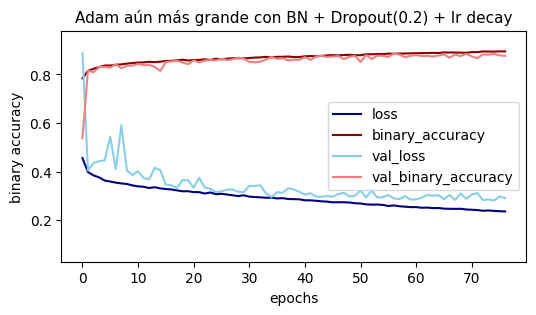

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn12.history))
ax1.legend(history_adam2_bn12.history.keys())

ax1.set_title('Adam aún más grande con BN + Dropout(0.2) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations4 = model5.evaluate(x=X_test, y=y_test, return_dict=True)

114/114 [==============================] - 1s 5ms/step - loss: 0.3423 - binary_accuracy: 0.8553


In [ ]:
st = time.time()

model6 = keras.models.Sequential()
model6.add(keras.layers.Dense(4096))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(4096))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(4096))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(2048))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(2048))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(2048))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(1024))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(512))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(256))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(128))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(64))
model6.add(keras.layers.BatchNormalization())
model6.add(keras.layers.Activation('leaky_relu'))
model6.add(keras.layers.Dropout(0.25))
model6.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 30, monitor='val_binary_accuracy', restore_best_weights=True)

lr_schedule = get_lr_schedule(training_size=32670, initial_learning_rate=0.001, initial_bs=128, decay_rate=0.98, staircase=True)
epochs = 200
batch_size = 128

model6.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_adam2_bn13 = model6.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam2_bn13 = time.time() - st

In [ ]:
print_results(history_adam2_bn13, cost_adam2_bn13)

Mejor accuracy de validación 0.891 en época 133 con accuracy de train 0.906
Diferencia error humano y accuracy de train 4.429 %
Diferencia accuracy de train y accuracy de validación 1.516 %
Número de épocas 164
Segundos de ejecución por época 7.933


(0.03, 0.98)

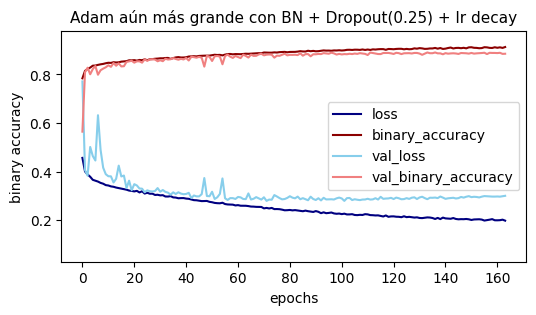

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_adam2_bn13.history))
ax1.legend(history_adam2_bn13.history.keys())

ax1.set_title('Adam aún más grande con BN + Dropout(0.25) + lr decay', fontsize = 11)

ax1.set_ylabel('binary accuracy')
ax1.set_xlabel('epochs')
ax1.set_ylim(0.03,0.98)

In [ ]:
evaluations5 = model6.evaluate(x=X_test, y=y_test, return_dict=True)

114/114 [==============================] - 1s 5ms/step - loss: 0.3483 - binary_accuracy: 0.8646



Matriz de confusión de las predicciones del modelo 6
114/114 [==============================] - 1s 4ms/step
[[ 855  306]
 [ 185 2281]]


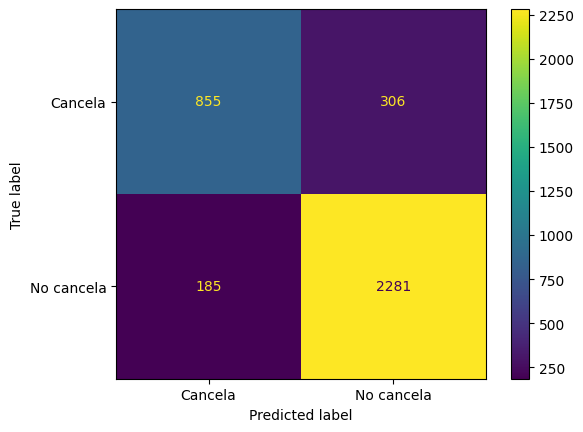

In [ ]:
print('\nMatriz de confusión de las predicciones del modelo 6')
y_prediction6 = model6.predict(X_test)
result6 = confusion_matrix(y_test, y_prediction6.round())
print(result6)

disp = ConfusionMatrixDisplay(confusion_matrix=result6, display_labels=["Cancela","No cancela"])
disp.plot()
plt.show()

In [ ]:
print("Precision_positive: ",result6[1][1]/(result6[1][1]+result6[0][1]))
print("Recall_positive: ",result6[1][1]/(result6[1][1]+result6[1][0]))

print("Precision_negative: ",result6[0][0]/(result6[0][0]+result6[1][0]))
print("Recall_negative: ",result6[0][0]/(result6[0][0]+result6[0][1]))

Precision_positive:  0.8817162736760726
Recall_positive:  0.9249797242497972
Precision_negative:  0.8221153846153846
Recall_negative:  0.7364341085271318


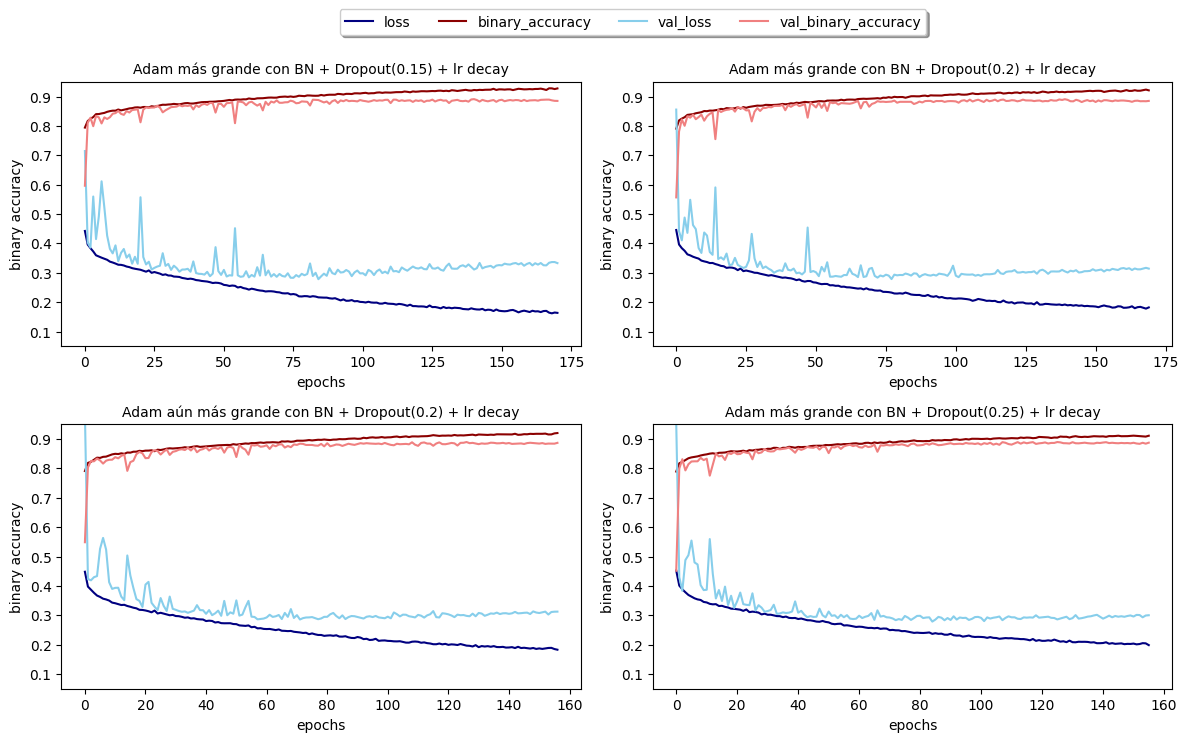

In [ ]:
fig1, ax1 = plt.subplots(2,2, figsize = (12,7))

ax1[0,0].plot(pd.DataFrame(history_adam2_bn7.history), label = 'Adam más grande con BN + Dropout(0.15) + lr decay')
ax1[0,1].plot(pd.DataFrame(history_adam2_bn8.history), label = 'Adam más grande con BN + Dropout(0.2) + lr decay')
ax1[1,0].plot(pd.DataFrame(history_adam2_bn9.history), label = 'Adam aún más grande con BN + Dropout(0.2) + lr decay')
ax1[1,1].plot(pd.DataFrame(history_adam2_bn13.history), label = 'Adam más grande con BN + Dropout(0.25) + lr decay')

for i in range(2):
    for j in range(2):
        ax1[i,j].set_xlabel('epochs')
        ax1[i,j].set_ylabel('binary accuracy')
        ax1[i,j].set_ylim(0.05,0.95)

ax1[0,0].set_title('Adam más grande con BN + Dropout(0.15) + lr decay', fontsize = 10)
ax1[0,1].set_title('Adam más grande con BN + Dropout(0.2) + lr decay', fontsize = 10)
ax1[1,0].set_title('Adam aún más grande con BN + Dropout(0.2) + lr decay', fontsize = 10)
ax1[1,1].set_title('Adam más grande con BN + Dropout(0.25) + lr decay', fontsize = 10)

plt.tight_layout()
ax1[0,0].legend(history_adam2_bn12.history.keys(), bbox_to_anchor=(1.1, 1.3), loc='upper center',  ncol=6, fancybox=True, shadow=True)


# basura

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(2048, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1024, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(512, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(256, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(128, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(64, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(32, activation='selu'))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

epochs = 200
batch_size = 32

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_batchnorm_after = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_batchnorm_after = time.time() - st

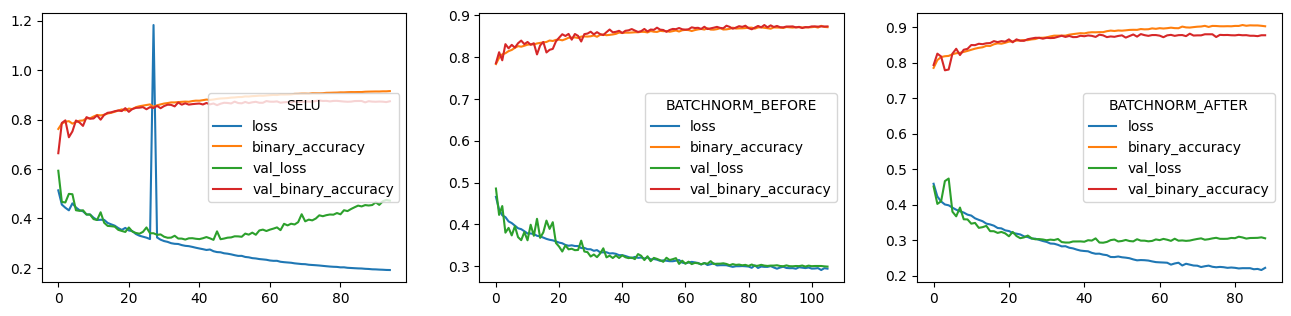

In [ ]:
fig1, ax1 = plt.subplots(1,3, figsize = (16,3.5))
ax1[0].plot(pd.DataFrame(history_adam_selu_lrate.history))
ax1[0].legend(history_adam_selu_lrate.history.keys(), title = 'SELU')
ax1[1].plot(pd.DataFrame(history_batchnorm_before.history))
ax1[1].legend(history_batchnorm_before.history.keys(), title = 'BATCHNORM_BEFORE')
ax1[2].plot(pd.DataFrame(history_batchnorm_after.history))
ax1[2].legend(history_batchnorm_after.history.keys(), title = 'BATCHNORM_AFTER')

In [ ]:
print('\nBATCHNORM_BEFORE')
print_results(history_batchnorm_before, cost_batchnorm_before)

print('\nBATCHNORM_AFTER')
print_results(history_batchnorm_after, cost_batchnorm_after)


BATCHNORM_BEFORE
Mejor accuracy de validación 0.877 en época 85 con accuracy de train 0.870
Diferencia error humano y accuracy de train 7.986 %
Diferencia accuracy de train y accuracy de validación -0.662 %
Número de épocas 106
Segundos de ejecución por época 7.372

BATCHNORM_AFTER
Mejor accuracy de validación 0.881 en época 68 con accuracy de train 0.898
Diferencia error humano y accuracy de train 5.156 %
Diferencia accuracy de train y accuracy de validación 1.727 %
Número de épocas 89
Segundos de ejecución por época 7.571


Hemos dismuido la varianza, aumenta el bias. Volvemos al ciclo inicial

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(2048))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(1024))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(512))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(256))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(128))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(64))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(32))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

epochs = 200
batch_size = 64

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_batchnorm_before_1 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_batchnorm_before_1 = time.time() - st

Text(0.5, 0, 'epochs')

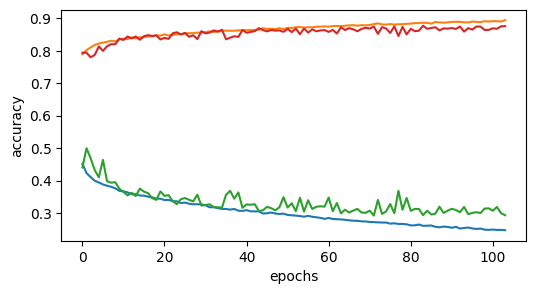

In [ ]:
fig1, ax1 = plt.subplots(figsize = (6,3))
ax1.plot(pd.DataFrame(history_batchnorm_before_1.history))
ax1.set_ylabel('accuracy')
ax1.set_xlabel('epochs')

In [ ]:
print('\nAUM_BATCH_SIZE')
print_results(history_batchnorm_before_1, cost_batchnorm_before_1)


AUM_BATCH_SIZE
Mejor accuracy de validación 0.877 en época 83 con accuracy de train 0.886
Diferencia error humano y accuracy de train 6.376 %
Diferencia accuracy de train y accuracy de validación 0.920 %
Número de épocas 104
Segundos de ejecución por época 4.232



Aumento del número de capas al haber disminuido la varianza

El batch_norm a disminuido la varianza pero ha aumentado levemente el bias, por lo que se aumentará el número de capas para mejorar este resultado

Añadimos regularizacion

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(4096,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(2048,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(2048,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(1024,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(1024,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(512,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(512,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(256,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(256,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(128,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(128,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(64,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(64,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(32,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(32,kernel_regularizer='l1',activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

epochs = 200
batch_size = 64

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_l1 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_l1 = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(4096,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(2048,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(2048,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(1024,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(1024,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(512,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(512,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(256,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(256,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(128,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(128,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(64,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(64,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(32,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(32,kernel_regularizer='l2',activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20)

epochs = 150
batch_size = 64

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_l2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_l2 = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(4096,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(4096,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(2048,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(2048,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(1024,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(1024,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(512,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(512,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(256,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(256,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(128,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(128,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(64,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(64,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(32,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(32,kernel_regularizer='l1_l2',activation='selu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20)

epochs = 150
batch_size = 64

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = lr_schedule) ,
              metrics = 'binary_accuracy')


history_l1_l2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_l1_l2 = time.time() - st

In [ ]:
fig1, ax1 = plt.subplots(1,3, figsize = (16,3.5))
ax1[0].plot(pd.DataFrame(history_l1.history))
ax1[0].legend(history_l1.history.keys(), title = 'L1')
ax1[1].plot(pd.DataFrame(history_l2.history))
ax1[1].legend(history_l2.history.keys(), title = 'L2')
ax1[2].plot(pd.DataFrame(history_l1_l2.history))
ax1[2].legend(history_l1_l2.history.keys(), title = 'L1_L2')

In [ ]:
print('\nL1')
print_results(history_l1, cost_l1)

print('\nL2')
print_results(history_l2, cost_l2)

print('\nL1_L2')
print_results(history_l1_l2, cost_l1_l2)

6. Pruebas con muchas capas

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20)

initial_lrate = 0.0001
epochs = 100
batch_size = 32

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'accuracy')


history_adam_3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_3 = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20)

initial_lrate = 0.0001
epochs = 100
batch_size = 32

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'accuracy')


history_adam_4 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_4 = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20)

initial_lrate = 0.0001
epochs = 100
batch_size = 32

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'accuracy')


history_adam_5 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_5 = time.time() - st

In [ ]:
costes = pd.DataFrame({'ADAM_1':pd.Series(cost_adam),
              'ADAM_2':pd.Series(cost_adam_2),
              'ADAM_3':pd.Series(cost_adam_3),
              'ADAM_4':pd.Series(cost_adam_4),
              'ADAM_5':pd.Series(cost_adam_5)})
costes = costes.T.reset_index()


fig1, ax1 = plt.subplots(2,3, figsize = (16,7))
ax1[0,0].plot(pd.DataFrame(history_adam.history), label = 'ADAM_1')
ax1[0,0].legend(history_adam.history.keys(), title = 'ADAM_1')
ax1[0,1].plot(pd.DataFrame(history_adam_2.history))
ax1[0,1].legend(history_adam_2.history.keys(), title = 'ADAM_2')
ax1[0,2].plot(pd.DataFrame(history_adam_3.history))
ax1[0,2].legend(history_adam_3.history.keys(), title = 'ADAM_3')
ax1[1,0].plot(pd.DataFrame(history_adam_4.history))
ax1[1,0].legend(history_adam_4.history.keys(), title = 'ADAM_4')
ax1[1,1].plot(pd.DataFrame(history_adam_5.history))
ax1[1,1].legend(history_adam_5.history.keys(), title = 'ADAM_5')
ax1[1,2].scatter(x =costes['index'], y = costes[0])
ax1[0,0].set_ylabel('accuracy')
ax1[0,0].set_xlabel('epochs')
ax1[0,1].set_ylabel('accuracy')
ax1[0,1].set_xlabel('epochs')
ax1[0,2].set_ylabel('accuracy')
ax1[0,2].set_xlabel('epochs')
ax1[1,0].set_ylabel('accuracy')
ax1[1,0].set_xlabel('epochs')
ax1[1,1].set_ylabel('accuracy')
ax1[1,1].set_xlabel('epochs')
ax1[1,2].set_ylabel('time')

In [ ]:
print('\nOPTIMIZADOR ADAM Base')
print_results(history_adam, cost_adam)

print('\nOPTIMIZADOR ADAM + 5 capas')
print_results(history_adam_2, cost_adam_2)

print('\nOPTIMIZADOR ADAM + 10 capas')
print_results(history_adam_3, cost_adam_3)

print('\nOPTIMIZADOR ADAM + 15 capas')
print_results(history_adam_4, cost_adam_4)

print('\nOPTIMIZADOR ADAM + 20 capas')
print_results(history_adam_5, cost_adam_5)

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.001
epochs = 200
batch_size = 32

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam_incr_asaaas = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_incr_asaaas = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.001
epochs = 200
batch_size = 128

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam_incr_2 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_incr_2 = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.001
epochs = 200
batch_size = 256

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam_incr_3 = model.fit(X_train, y_train,
                    epochs=epochs,
                    batch_size = batch_size,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_incr_3 = time.time() - st

In [ ]:
st = time.time()

model = keras.models.Sequential()
model.add(keras.layers.Dense(2048, activation='relu'))
model.add(keras.layers.Dense(1024, activation='relu'))
model.add(keras.layers.Dense(512, activation='relu'))
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(64, activation='relu'))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dense(1, activation = 'sigmoid'))

early_stopping_cb = keras.callbacks.EarlyStopping(patience = 20, monitor='val_binary_accuracy')

initial_lrate = 0.001
epochs = 200

model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(learning_rate = initial_lrate) ,
              metrics = 'binary_accuracy')


history_adam_sin_minibatch = model.fit(X_train, y_train,
                    epochs=epochs,
                    verbose=0,
                    validation_data = (X_dev, y_dev),
                    callbacks = [early_stopping_cb])

cost_adam_sin_minibatch = time.time() - st

In [ ]:
print('\nOPTIMIZADOR ADAM 32 batch size')
print_results(history_adam_incr_asaaas, cost_adam_incr_asaaas)

print('\nOPTIMIZADOR ADAM 128 batch size')
print_results(history_adam_incr_2, cost_adam_incr_2)

print('\nOPTIMIZADOR ADAM sin batch size')
print_results(history_adam_sin_minibatch, cost_adam_sin_minibatch)

print('\nOPTIMIZADOR ADAM 256 batch size')
print_results(history_adam_incr_3, cost_adam_incr_3)




OPTIMIZADOR ADAM 32 batch size
Mejor accuracy de validación 0.878 en época 34 con accuracy de train 0.890
Diferencia error humano y accuracy de train 5.970 %
Diferencia accuracy de train y accuracy de validación 1.272 %
Número de épocas 55
Segundos de ejecución por época 5.119

OPTIMIZADOR ADAM 128 batch size
Mejor accuracy de validación 0.880 en época 44 con accuracy de train 0.911
Diferencia error humano y accuracy de train 3.943 %
Diferencia accuracy de train y accuracy de validación 3.050 %
Número de épocas 65
Segundos de ejecución por época 1.887

OPTIMIZADOR ADAM sin batch size
Mejor accuracy de validación 0.876 en época 41 con accuracy de train 0.896
Diferencia error humano y accuracy de train 5.367 %
Diferencia accuracy de train y accuracy de validación 1.985 %
Número de épocas 62
Segundos de ejecución por época 4.725

OPTIMIZADOR ADAM 256 batch size
Mejor accuracy de validación 0.879 en época 43 con accuracy de train 0.907
Diferencia error humano y accuracy de train 4.295 %
D

## Cosas de grid search de hiper parámetros (¿Janire?)

In [ ]:
score, accuracy = model.evaluate(X_dev, y_dev, verbose=0)

print("Score: ",score)
print("Accuracy: ",accuracy)

In [ ]:
'''
def data() :

  return x_train, y_train, x_dev, y_dev
def model(X_train, y_train, X_test, y_test):
    model = keras.models.Sequential()

    model.add(keras.layers.Dense({{choice([32, 64, 128])}}, activation='relu'))
    model.add(keras.layers.Dense({{choice([32, 64, 128])}}, activation='relu'))
    model.add(keras.layers.Dense(1, activation = 'sigmoid'))

    early_stopping_cb = keras.callbacks.EarlyStopping(patience = 10)

    initial_lrate = {{choice([0.01, 0.01])}}
    epochs = 10


    def exp_decay(epoch, initial_lrate):
        k = initial_lrate
        lrate = initial_lrate * np.exp(-k*epoch)
        return lrate
    lrate = tf.keras.callbacks.LearningRateScheduler(exp_decay)

    model.compile(loss = "binary_crossentropy", optimizer = keras.optimizers.Adam(lr = initial_lrate) ,
                  metrics = 'accuracy')


    history = model.fit(X_train, y_train,
                        epochs=epochs,
                        verbose=2,
                        validation_data = (X_test, y_test),
                        callbacks = [early_stopping_cb])



    return { 'status': STATUS_OK, 'model': model, 'history.val_loss':history.history['val_loss'], 'history.val_mae': history.history['val_mae'],
    'history.loss': history.history['loss'], 'history.mae': history.history['mae'], 'history.lr': history.history['lr']}

trials = Trials()
best_run, best_model= hyperas.optim.minimize(model=model,
                                          data=data,
                                          max_evals=200,
                                          algo=hyperopt.tpe.suggest,
                                          notebook_name='/content/drive/MyDrive/Redes_neuronas/P1_RNyDL',
                                          trials=trials,
                                          eval_space=True)

print("")

'''